In [1]:
import warnings
import time
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

from google.colab import drive

warnings.filterwarnings('ignore', category=UserWarning)
print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv("/content/hour.csv")
print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [5]:
print("Shape:", df.shape)
df.info()
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (17379, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB

Columns: ['instant', 'dteday'

In [6]:
df["dteday"] = pd.to_datetime(df["dteday"])

print(df["dteday"].dtype)

datetime64[ns]


In [7]:
invalid_hr = ((df["hr"] < 0) | (df["hr"] > 23)).sum()

print("Invalid hour values:", invalid_hr)

invalid_hum = ((df["hum"] < 0) | (df["hum"] > 1)).sum()

print("Invalid humidity values:", invalid_hum)

invalid_temp = ((df["temp"] < 0) | (df["temp"] > 1)).sum()

print("Invalid temperature values:", invalid_temp)

invalid_wind = ((df["windspeed"] < 0) | (df["windspeed"] > 1)).sum()

print("Invalid windspeed values:", invalid_wind)

Invalid hour values: 0
Invalid humidity values: 0
Invalid temperature values: 0
Invalid windspeed values: 0


In [8]:
Q1 = df["cnt"].quantile(0.25)
Q3 = df["cnt"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["cnt"] < lower_limit) |
    (df["cnt"] > upper_limit)
]

print("Number of potential outliers:", len(outliers))

Number of potential outliers: 505


In [9]:
df = df.sort_values(
    by=["dteday", "hr"]
).reset_index(drop=True)

print(df.head())

   instant     dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1 2011-01-01       1   0     1   0        0        6           0   
1        2 2011-01-01       1   0     1   1        0        6           0   
2        3 2011-01-01       1   0     1   2        0        6           0   
3        4 2011-01-01       1   0     1   3        0        6           0   
4        5 2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  


In [11]:
df.to_csv("/content/cleaned_bike_sharing.csv", index=False)

In [12]:
quality_log = {
    "Rows": len(df),
    "Columns": len(df.columns),
    "Missing Values": int(df.isnull().sum().sum()),
    "Duplicate Rows": int(df.duplicated().sum()),
    "Invalid Hour Values": int(((df["hr"] < 0) | (df["hr"] > 23)).sum())
}

quality_df = pd.DataFrame([quality_log])

print(quality_df)

quality_df.to_csv("data_quality_log.csv", index=False)

    Rows  Columns  Missing Values  Duplicate Rows  Invalid Hour Values
0  17379       17               0               0                    0


In [13]:
COLORS = {
    'blue':   '#2F6DB5',
    'orange': '#F28E2B',
    'green':  '#3C9D5D',
    'red':    '#D64550',
    'teal':   '#1B998B',
    'purple': '#7A5AA6',
    'gold':   '#E5B12E',
}
PALETTE   = list(COLORS.values())
TEXT_DARK = '#1F2937'
GRID_GREY = '#E5E9F0'
EDGE_GREY = '#CBD2DC'

# Semantic colours reused across the notebook so the same category always looks the same
DAY_COLORS = {'Non-Working Day': COLORS['orange'], 'Working Day': COLORS['blue']}
WEATHER_ORDER = ['Clear', 'Mist/Cloudy', 'Light Rain/Snow', 'Heavy Rain/Snow']
WEATHER_COLORS = dict(zip(
    WEATHER_ORDER,
    [COLORS['green'], COLORS['blue'], COLORS['orange'], COLORS['red']]
))

sns.set_theme(style="whitegrid", rc={
    'figure.figsize': (10, 5.5),
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'text.color': TEXT_DARK,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.labelcolor': TEXT_DARK,
    'axes.edgecolor': EDGE_GREY,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.axisbelow': True,
    'axes.prop_cycle': plt.cycler(color=PALETTE),
    'grid.color': GRID_GREY,
    'grid.linewidth': 0.8,
    'xtick.color': TEXT_DARK,
    'ytick.color': TEXT_DARK,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.framealpha': 0.95,
    'legend.edgecolor': EDGE_GREY,
    'legend.facecolor': 'white',
    'legend.fontsize': 10,
    'legend.title_fontsize': 11,
})


def darken(color, factor=0.6):
    """Return a darker shade of a colour (used for KDE curves)."""
    return tuple(factor * c for c in to_rgb(color))


def style_axes(ax, title, xlabel=None, ylabel=None, grid_axis='y'):
    """Consistent title, labels and light gridlines for every chart."""
    ax.set_title(title, loc='left', fontsize=14, fontweight='bold', color=TEXT_DARK, pad=12)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.grid(False)
    if grid_axis in ('x', 'y'):
        ax.grid(True, axis=grid_axis, color=GRID_GREY, linewidth=0.8)
    elif grid_axis == 'both':
        ax.grid(True, color=GRID_GREY, linewidth=0.8)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)


def add_legend(ax, handles=None, title=None, loc='best', outside=False, fontsize=10):
    """Clean, boxed legend. outside=True places it to the right of the plot area."""
    kwargs = {'loc': 'center left', 'bbox_to_anchor': (1.02, 0.5)} if outside else {'loc': loc}
    leg = ax.legend(handles=handles, title=title, frameon=True, fancybox=True,
                    framealpha=0.95, edgecolor=EDGE_GREY, facecolor='white',
                    fontsize=fontsize, **kwargs)
    leg.get_title().set_fontweight('bold')
    return leg


def hist_panel(ax, col, color, name, xlabel, title, loc='upper right', fontsize=10, bins=40):
    """Histogram + KDE with mean/median reference lines and a boxed legend."""
    sns.histplot(data=df, x=col, bins=bins, kde=True, color=color, alpha=0.75,
                 edgecolor='white', linewidth=0.6, ax=ax)
    kde_line = ax.lines[0]
    kde_line.set_color(darken(color))
    kde_line.set_linewidth(2.4)

    mean_v, median_v = df[col].mean(), df[col].median()
    ax.axvline(mean_v, color=COLORS['red'], linestyle='--', linewidth=1.8)
    ax.axvline(median_v, color=TEXT_DARK, linestyle=':', linewidth=2)

    handles = [
        Patch(facecolor=color, edgecolor='white', alpha=0.75, label='Histogram'),
        Line2D([0], [0], color=darken(color), linewidth=2.4, label='KDE curve'),
        Line2D([0], [0], color=COLORS['red'], linestyle='--', linewidth=1.8, label=f'Mean = {mean_v:,.2f}'),
        Line2D([0], [0], color=TEXT_DARK, linestyle=':', linewidth=2, label=f'Median = {median_v:,.2f}'),
    ]
    ax.set_ylim(top=ax.get_ylim()[1] * 1.32)   # head-room so the legend never covers the bars
    style_axes(ax, title, xlabel, 'Frequency')
    add_legend(ax, handles, title=name, loc=loc, fontsize=fontsize)

In [14]:
df.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


In [15]:
print("Start date:", df['dteday'].min())
print("End date:", df['dteday'].max())

print("Minimum demand:", df['cnt'].min())
print("Maximum demand:", df['cnt'].max())
print("Average demand:", df['cnt'].mean())

Start date: 2011-01-01 00:00:00
End date: 2012-12-31 00:00:00
Minimum demand: 1
Maximum demand: 977
Average demand: 189.46308763450142


In [16]:
numeric_cols = [
    'temp', 'atemp', 'hum', 'windspeed',
    'casual', 'registered', 'cnt'
]

categorical_cols = [
    'season', 'yr', 'mnth', 'hr',
    'holiday', 'weekday', 'workingday', 'weathersit'
]

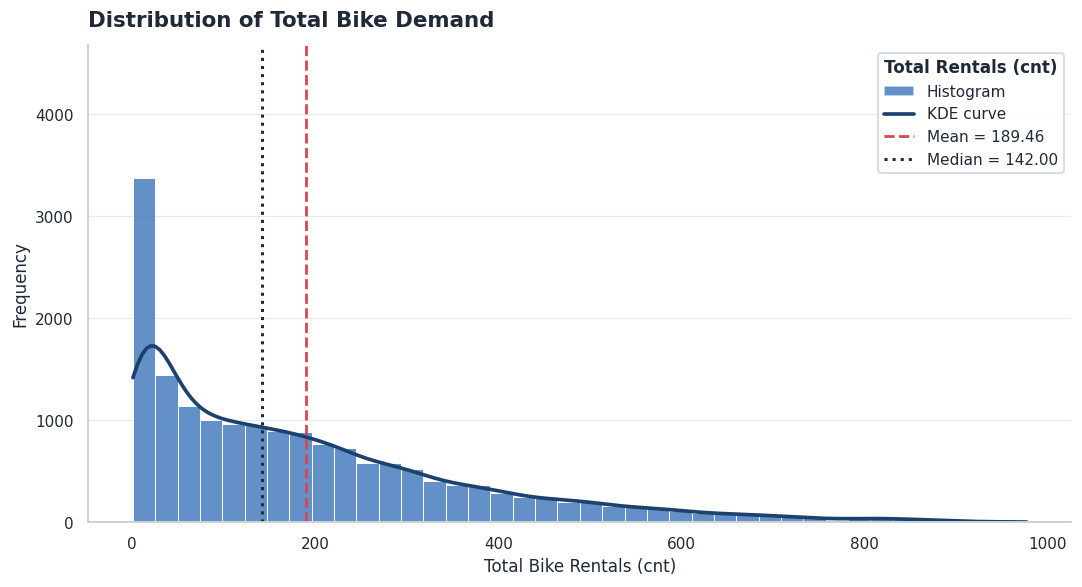

In [17]:
fig, ax = plt.subplots(figsize=(10, 5.5))
hist_panel(ax, 'cnt', COLORS['blue'], 'Total Rentals (cnt)',
           'Total Bike Rentals (cnt)', 'Distribution of Total Bike Demand', loc='upper right')
plt.tight_layout()
plt.show()

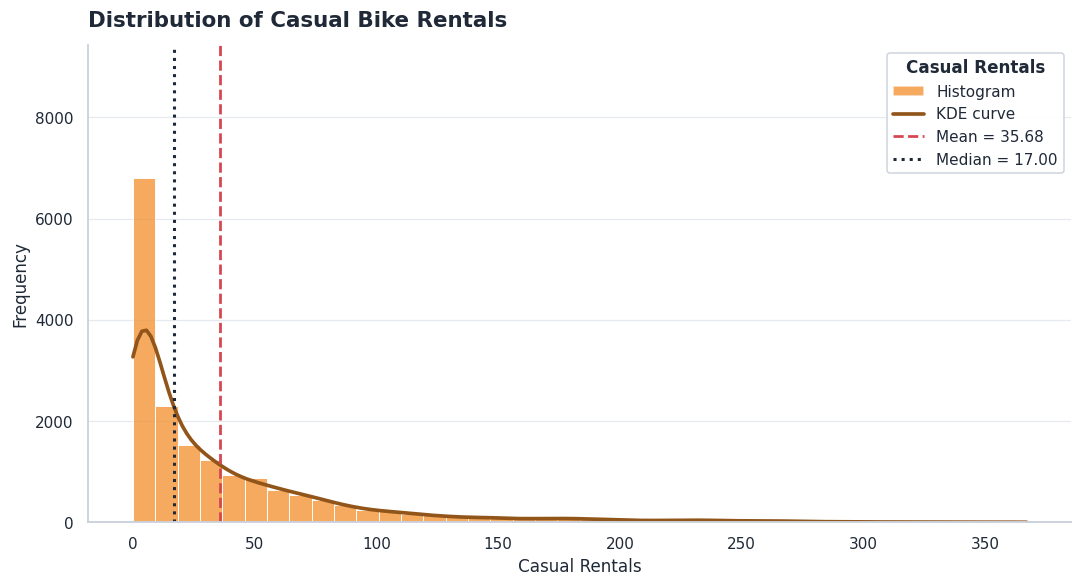

In [18]:
fig, ax = plt.subplots(figsize=(10, 5.5))
hist_panel(ax, 'casual', COLORS['orange'], 'Casual Rentals',
           'Casual Rentals', 'Distribution of Casual Bike Rentals', loc='upper right')
plt.tight_layout()
plt.show()

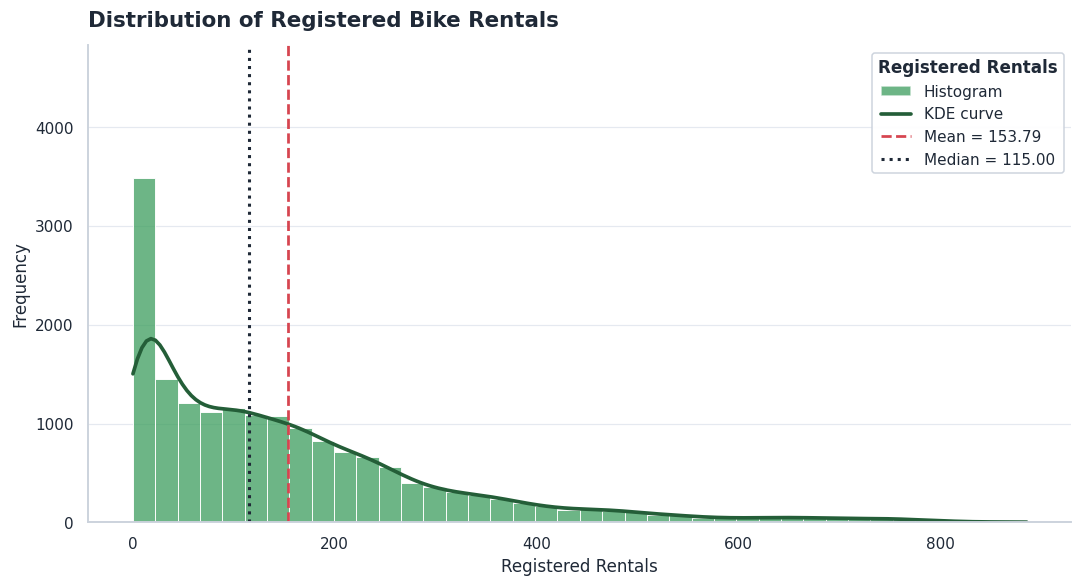

In [19]:
fig, ax = plt.subplots(figsize=(10, 5.5))
hist_panel(ax, 'registered', COLORS['green'], 'Registered Rentals',
           'Registered Rentals', 'Distribution of Registered Bike Rentals', loc='upper right')
plt.tight_layout()
plt.show()

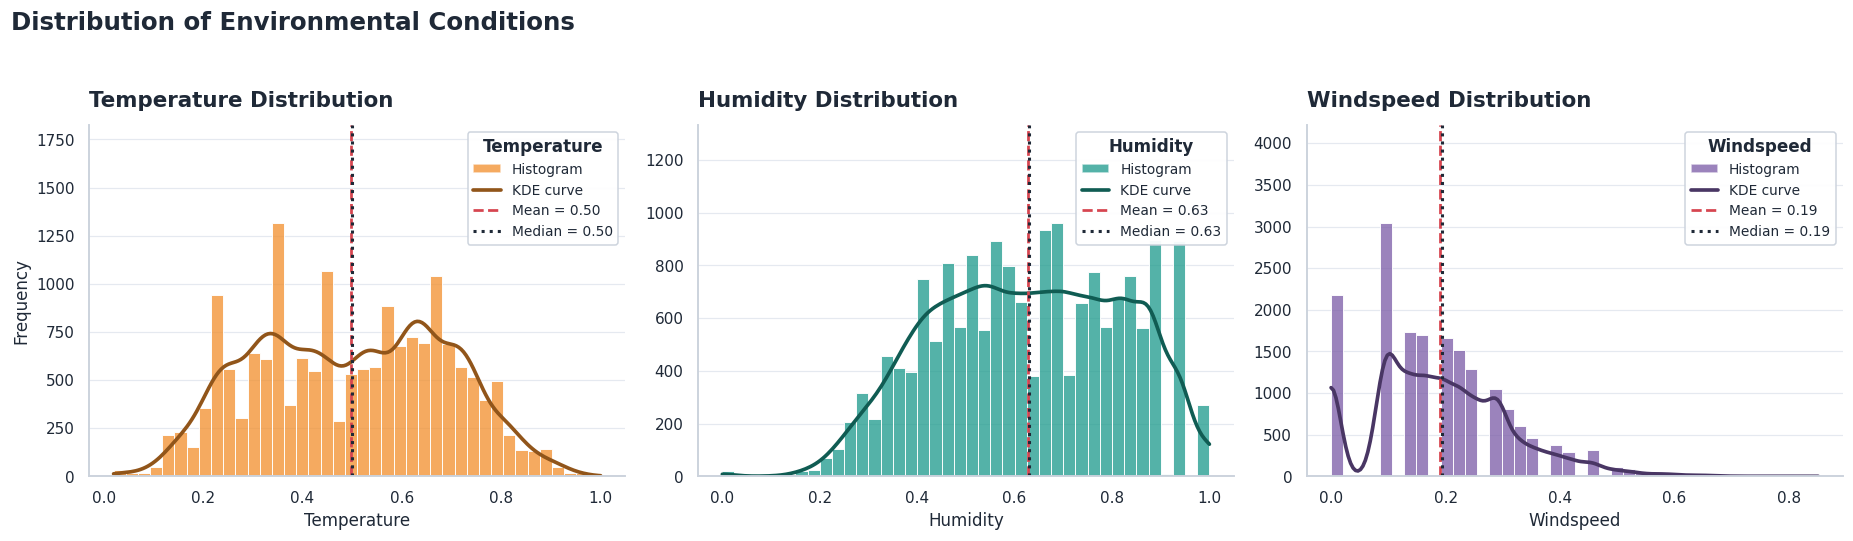

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

hist_panel(axes[0], 'temp', COLORS['orange'], 'Temperature',
           'Temperature', 'Temperature Distribution', fontsize=9)
hist_panel(axes[1], 'hum', COLORS['teal'], 'Humidity',
           'Humidity', 'Humidity Distribution', fontsize=9)
hist_panel(axes[2], 'windspeed', COLORS['purple'], 'Windspeed',
           'Windspeed', 'Windspeed Distribution', fontsize=9)

for ax in axes[1:]:
    ax.set_ylabel('')

fig.suptitle('Distribution of Environmental Conditions', x=0.01, ha='left',
             fontsize=16, fontweight='bold', color=TEXT_DARK)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [21]:
skewness = df[numeric_cols].skew().sort_values(ascending=False)
skewness

,0
casual,2.499237
registered,1.557904
cnt,1.277412
windspeed,0.574905
temp,-0.006021
atemp,-0.090429
hum,-0.111287


In [22]:
skewness_table = pd.DataFrame({
    'Feature': skewness.index,
    'Skewness': skewness.values
})

skewness_table['Interpretation'] = skewness_table['Skewness'].apply(
    lambda x: 'Right-skewed' if x > 0.5
    else ('Left-skewed' if x < -0.5 else 'Approximately symmetric')
)

skewness_table

,Feature,Skewness,Interpretation
0,casual,2.499237,Right-skewed
1,registered,1.557904,Right-skewed
2,cnt,1.277412,Right-skewed
3,windspeed,0.574905,Right-skewed
4,temp,-0.006021,Approximately symmetric
5,atemp,-0.090429,Approximately symmetric
6,hum,-0.111287,Approximately symmetric


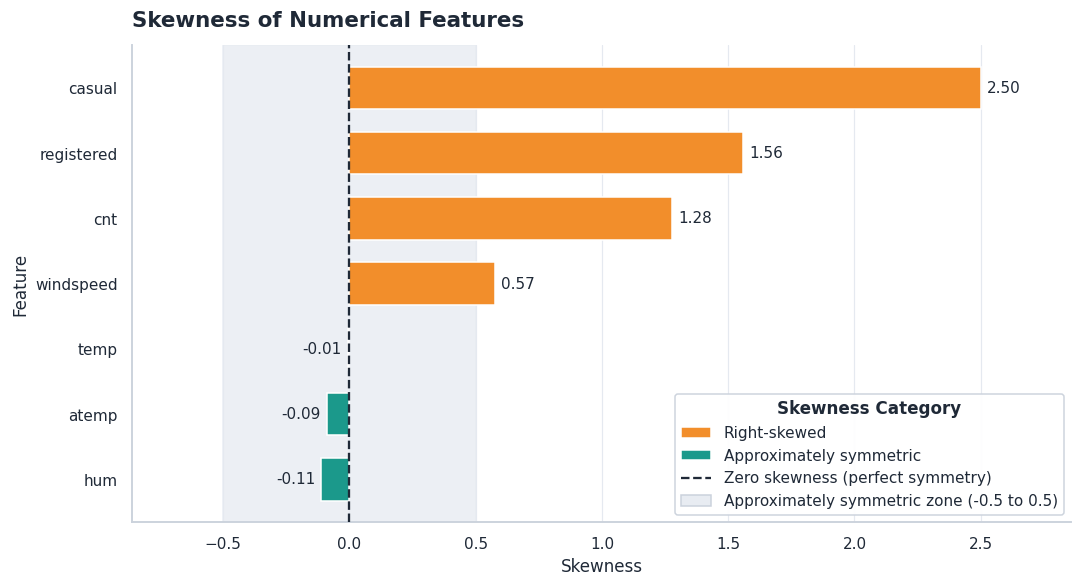

In [23]:
skew_colors = {
    'Right-skewed': COLORS['orange'],
    'Left-skewed': COLORS['purple'],
    'Approximately symmetric': COLORS['teal'],
}
SYM_ZONE = '#E8ECF2'

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axvspan(-0.5, 0.5, color=SYM_ZONE, alpha=0.8, zorder=0)
bars = ax.barh(
    skewness_table['Feature'], skewness_table['Skewness'],
    color=skewness_table['Interpretation'].map(skew_colors).tolist(),
    edgecolor='white', height=0.65, zorder=2
)
ax.axvline(0, color=TEXT_DARK, linestyle='--', linewidth=1.5, zorder=3)
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=10, color=TEXT_DARK)
ax.invert_yaxis()
ax.margins(x=0.12)
style_axes(ax, 'Skewness of Numerical Features', 'Skewness', 'Feature', grid_axis='x')

present = set(skewness_table['Interpretation'])
handles = [Patch(facecolor=c, label=k) for k, c in skew_colors.items() if k in present]
handles += [
    Line2D([0], [0], color=TEXT_DARK, linestyle='--', linewidth=1.5, label='Zero skewness (perfect symmetry)'),
    Patch(facecolor=SYM_ZONE, edgecolor=EDGE_GREY, label='Approximately symmetric zone (-0.5 to 0.5)'),
]
add_legend(ax, handles, title='Skewness Category', loc='lower right')
plt.tight_layout()
plt.show()

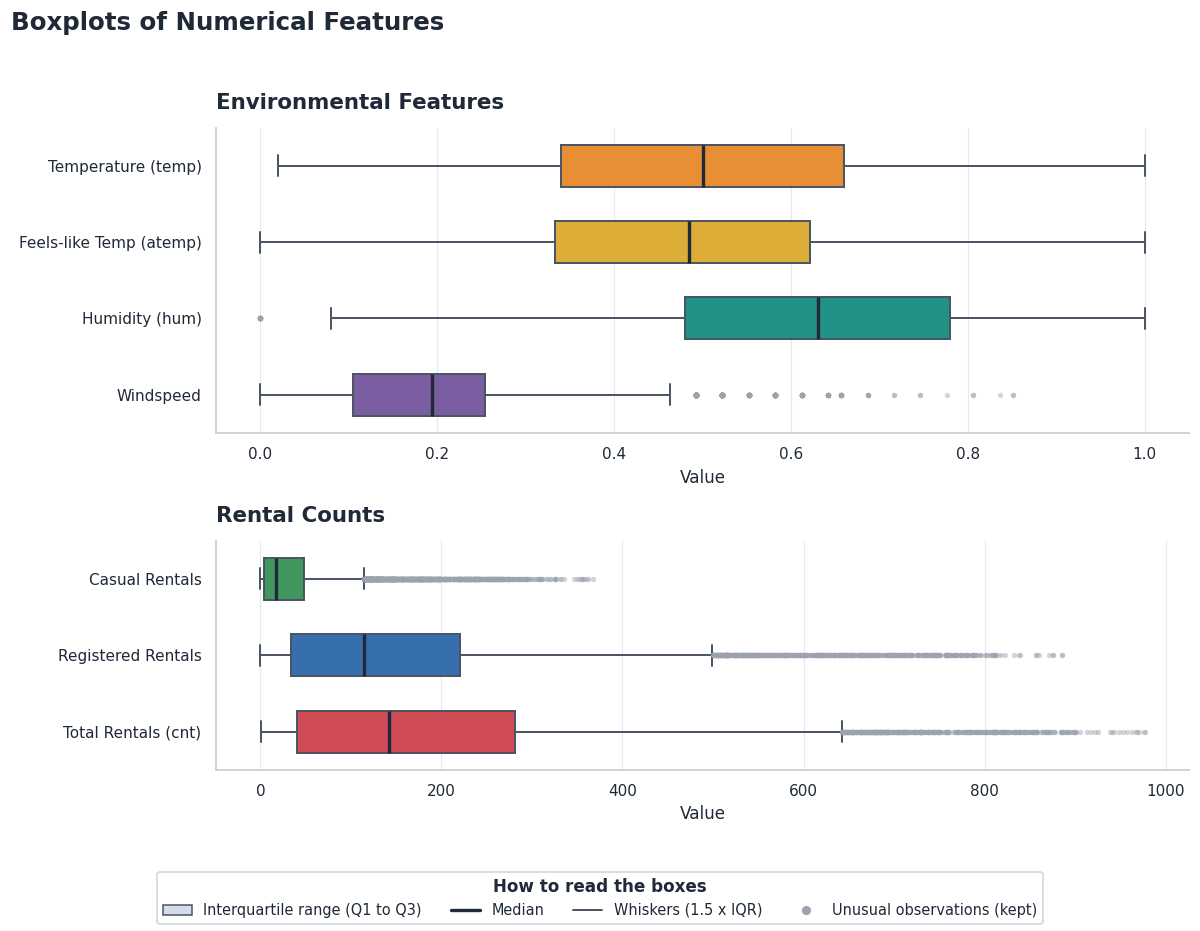

In [24]:
plot_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

box_labels = {
    'temp': 'Temperature (temp)',
    'atemp': 'Feels-like Temp (atemp)',
    'hum': 'Humidity (hum)',
    'windspeed': 'Windspeed',
    'casual': 'Casual Rentals',
    'registered': 'Registered Rentals',
    'cnt': 'Total Rentals (cnt)',
}
box_colors = dict(zip(
    plot_cols,
    [COLORS['orange'], COLORS['gold'], COLORS['teal'], COLORS['purple'],
     COLORS['green'], COLORS['blue'], COLORS['red']]
))
# Two panels because the weather variables and the rental counts are on very different scales
box_groups = [
    ('Environmental Features', ['temp', 'atemp', 'hum', 'windspeed']),
    ('Rental Counts', ['casual', 'registered', 'cnt']),
]

fig, axes = plt.subplots(2, 1, figsize=(11, 8.5), gridspec_kw={'height_ratios': [4, 3]})

for ax, (group_title, cols) in zip(axes, box_groups):
    long_df = df[cols].rename(columns=box_labels).melt(var_name='Feature', value_name='Value')
    order = [box_labels[c] for c in cols]
    sns.boxplot(
        data=long_df, x='Value', y='Feature', hue='Feature',
        order=order, hue_order=order,
        palette={box_labels[c]: box_colors[c] for c in cols},
        orient='h', legend=False, width=0.55, linewidth=1.3, saturation=0.9,
        linecolor='#4B5563',
        medianprops={'color': TEXT_DARK, 'linewidth': 2.2},
        flierprops={'marker': 'o', 'markerfacecolor': '#9CA3AF', 'markeredgecolor': 'none',
                    'markersize': 3.5, 'alpha': 0.45},
        ax=ax
    )
    style_axes(ax, group_title, 'Value', '', grid_axis='x')

fig.suptitle('Boxplots of Numerical Features', x=0.01, ha='left',
             fontsize=16, fontweight='bold', color=TEXT_DARK)

legend_handles = [
    Patch(facecolor='#D5DDEA', edgecolor='#4B5563', label='Interquartile range (Q1 to Q3)'),
    Line2D([0], [0], color=TEXT_DARK, linewidth=2.2, label='Median'),
    Line2D([0], [0], color='#4B5563', linewidth=1.3, label='Whiskers (1.5 x IQR)'),
    Line2D([0], [0], marker='o', linestyle='none', markerfacecolor='#9CA3AF',
           markeredgecolor='none', markersize=6, label='Unusual observations (kept)'),
]
leg = fig.legend(handles=legend_handles, loc='lower center', ncol=4, title='How to read the boxes',
                 frameon=True, fancybox=True, edgecolor=EDGE_GREY, facecolor='white', fontsize=9.5)
leg.get_title().set_fontweight('bold')

plt.tight_layout(rect=[0, 0.09, 1, 0.96])
plt.show()

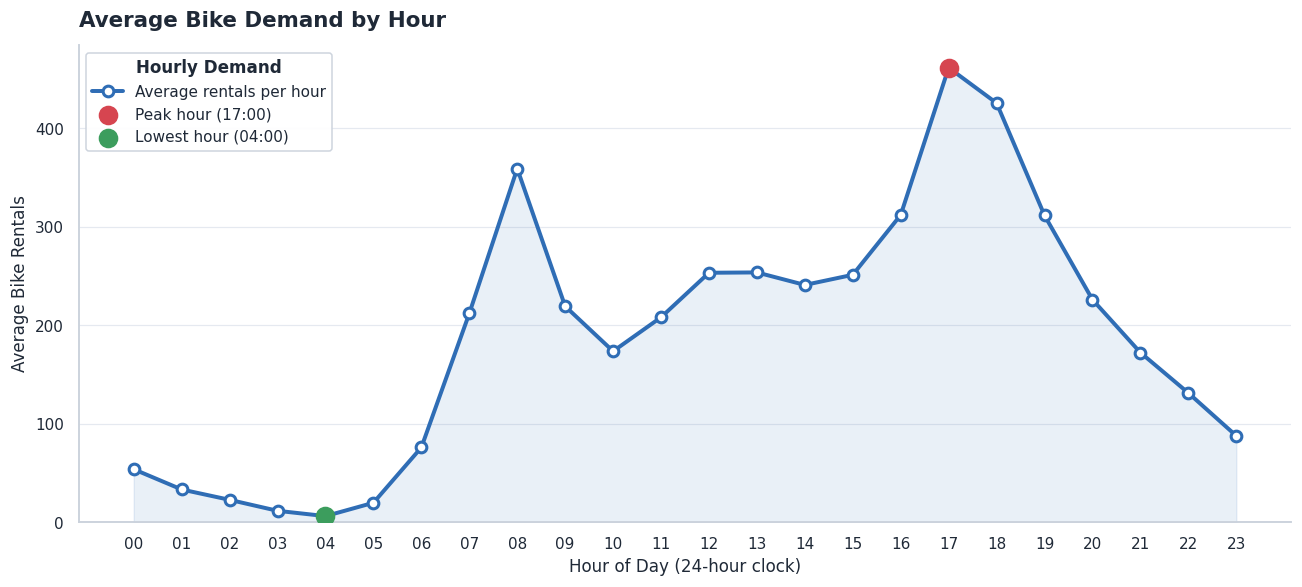

In [25]:
hourly_demand = df.groupby('hr')['cnt'].mean()
peak_hr, low_hr = hourly_demand.idxmax(), hourly_demand.idxmin()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(hourly_demand.index, hourly_demand.values, color=COLORS['blue'], linewidth=2.6,
        marker='o', markersize=7, markerfacecolor='white', markeredgewidth=2,
        label='Average rentals per hour')
ax.fill_between(hourly_demand.index, hourly_demand.values, color=COLORS['blue'], alpha=0.10)
ax.scatter(peak_hr, hourly_demand[peak_hr], s=140, color=COLORS['red'], zorder=5,
           label=f'Peak hour ({peak_hr:02d}:00)')
ax.scatter(low_hr, hourly_demand[low_hr], s=140, color=COLORS['green'], zorder=5,
           label=f'Lowest hour ({low_hr:02d}:00)')

ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}' for h in range(24)])
ax.set_ylim(bottom=0)
style_axes(ax, 'Average Bike Demand by Hour', 'Hour of Day (24-hour clock)', 'Average Bike Rentals')
add_legend(ax, title='Hourly Demand', loc='upper left')
plt.tight_layout()
plt.show()

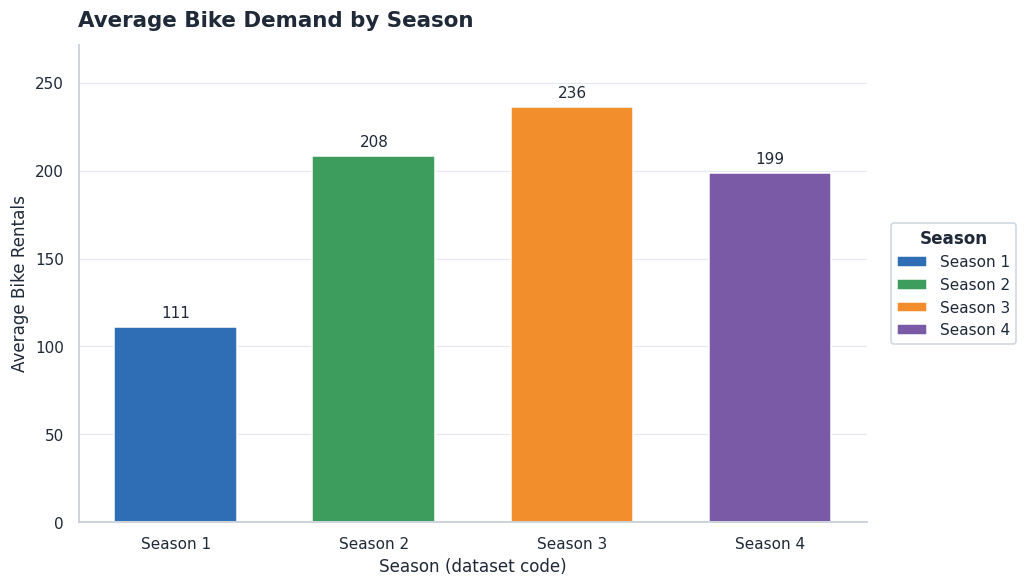

In [26]:
season_demand = df.groupby('season')['cnt'].mean()
season_labels = [f'Season {s}' for s in season_demand.index]
season_colors = [COLORS['blue'], COLORS['green'], COLORS['orange'], COLORS['purple']][:len(season_labels)]

fig, ax = plt.subplots(figsize=(9.5, 5.5))
bars = ax.bar(season_labels, season_demand.values, color=season_colors, edgecolor='white', width=0.62)
ax.bar_label(bars, fmt='%.0f', padding=4, fontsize=10, color=TEXT_DARK)
ax.set_ylim(0, season_demand.max() * 1.15)
style_axes(ax, 'Average Bike Demand by Season', 'Season (dataset code)', 'Average Bike Rentals')
add_legend(ax, [Patch(facecolor=c, label=l) for c, l in zip(season_colors, season_labels)],
           title='Season', outside=True)
plt.tight_layout()
plt.show()

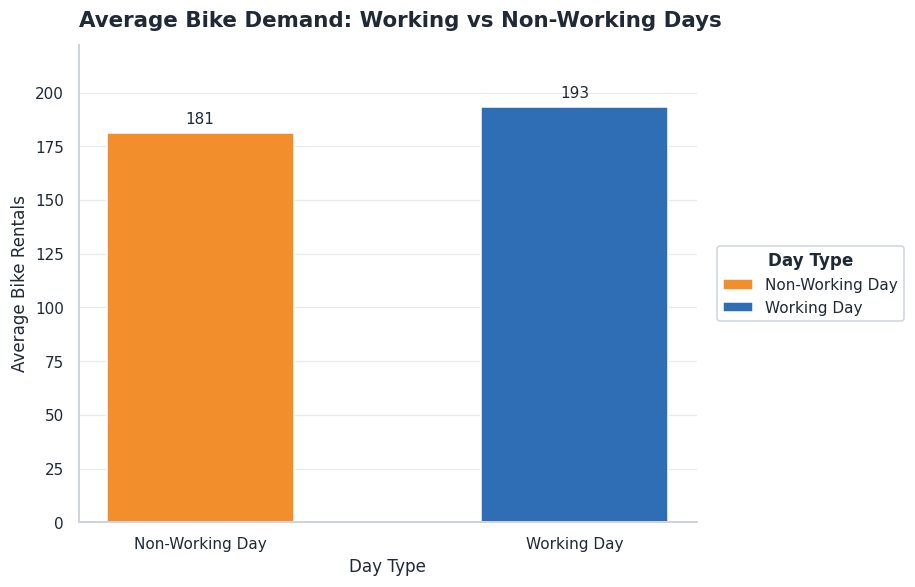

In [27]:
workingday_demand = df.groupby('workingday')['cnt'].mean()
day_labels = ['Working Day' if d == 1 else 'Non-Working Day' for d in workingday_demand.index]
day_colors = [DAY_COLORS[l] for l in day_labels]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
bars = ax.bar(day_labels, workingday_demand.values, color=day_colors, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.0f', padding=4, fontsize=10, color=TEXT_DARK)
ax.set_ylim(0, workingday_demand.max() * 1.15)
style_axes(ax, 'Average Bike Demand: Working vs Non-Working Days', 'Day Type', 'Average Bike Rentals')
add_legend(ax, [Patch(facecolor=c, label=l) for l, c in zip(day_labels, day_colors)],
           title='Day Type', outside=True)
plt.tight_layout()
plt.show()

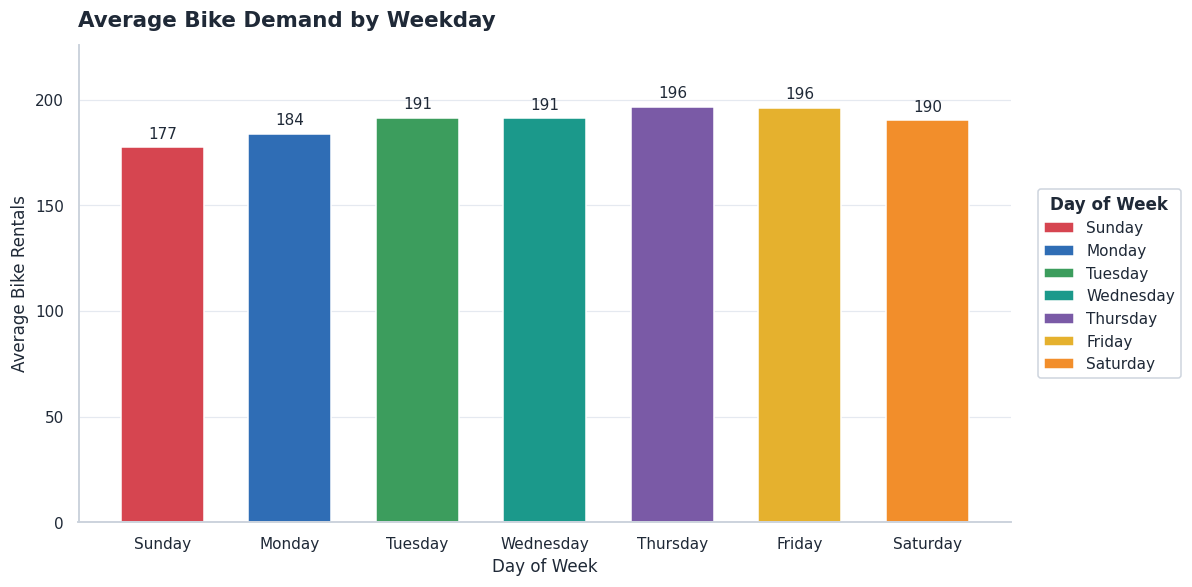

In [28]:
weekday_labels = {
    0: 'Sunday',
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday'
}

weekday_demand = (
    df.groupby('weekday')['cnt']
    .mean()
    .reindex(range(7))
)

weekday_names = [weekday_labels[i] for i in weekday_demand.index]
weekday_colors = [COLORS['red'], COLORS['blue'], COLORS['green'], COLORS['teal'],
                  COLORS['purple'], COLORS['gold'], COLORS['orange']]

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(weekday_names, weekday_demand.values, color=weekday_colors, edgecolor='white', width=0.65)
ax.bar_label(bars, fmt='%.0f', padding=4, fontsize=10, color=TEXT_DARK)
ax.set_ylim(0, weekday_demand.max() * 1.15)
style_axes(ax, 'Average Bike Demand by Weekday', 'Day of Week', 'Average Bike Rentals')
add_legend(ax, [Patch(facecolor=c, label=n) for c, n in zip(weekday_colors, weekday_names)],
           title='Day of Week', outside=True)
plt.tight_layout()
plt.show()

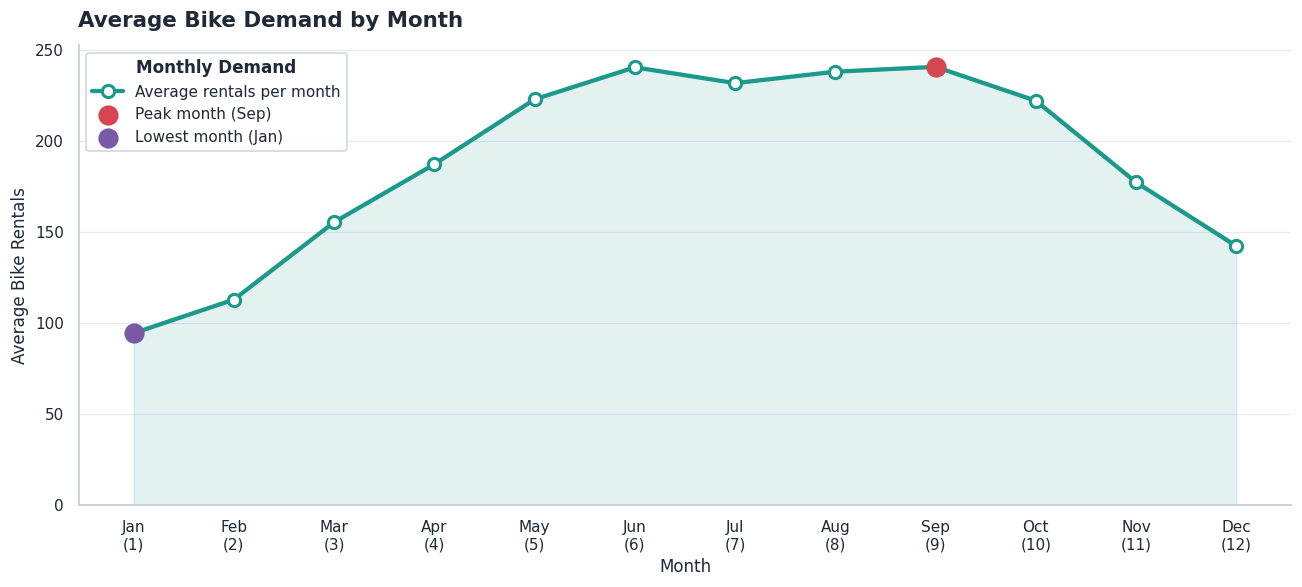

In [29]:
month_demand = (
    df.groupby('mnth')['cnt']
    .mean()
    .reindex(range(1, 13))
)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
peak_m, low_m = month_demand.idxmax(), month_demand.idxmin()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(month_demand.index, month_demand.values, color=COLORS['teal'], linewidth=2.8,
        solid_joinstyle='round', marker='o', markersize=8, markerfacecolor='white',
        markeredgewidth=2, label='Average rentals per month')
ax.fill_between(month_demand.index, month_demand.values, color=COLORS['teal'], alpha=0.12)
ax.scatter(peak_m, month_demand[peak_m], s=150, color=COLORS['red'], zorder=5,
           label=f'Peak month ({month_names[peak_m - 1]})')
ax.scatter(low_m, month_demand[low_m], s=150, color=COLORS['purple'], zorder=5,
           label=f'Lowest month ({month_names[low_m - 1]})')

ax.set_xticks(range(1, 13))
ax.set_xticklabels([f'{m}\n({i})' for i, m in enumerate(month_names, start=1)])
ax.set_ylim(bottom=0)
style_axes(ax, 'Average Bike Demand by Month', 'Month', 'Average Bike Rentals')
add_legend(ax, title='Monthly Demand', loc='upper left')
plt.tight_layout()
plt.show()

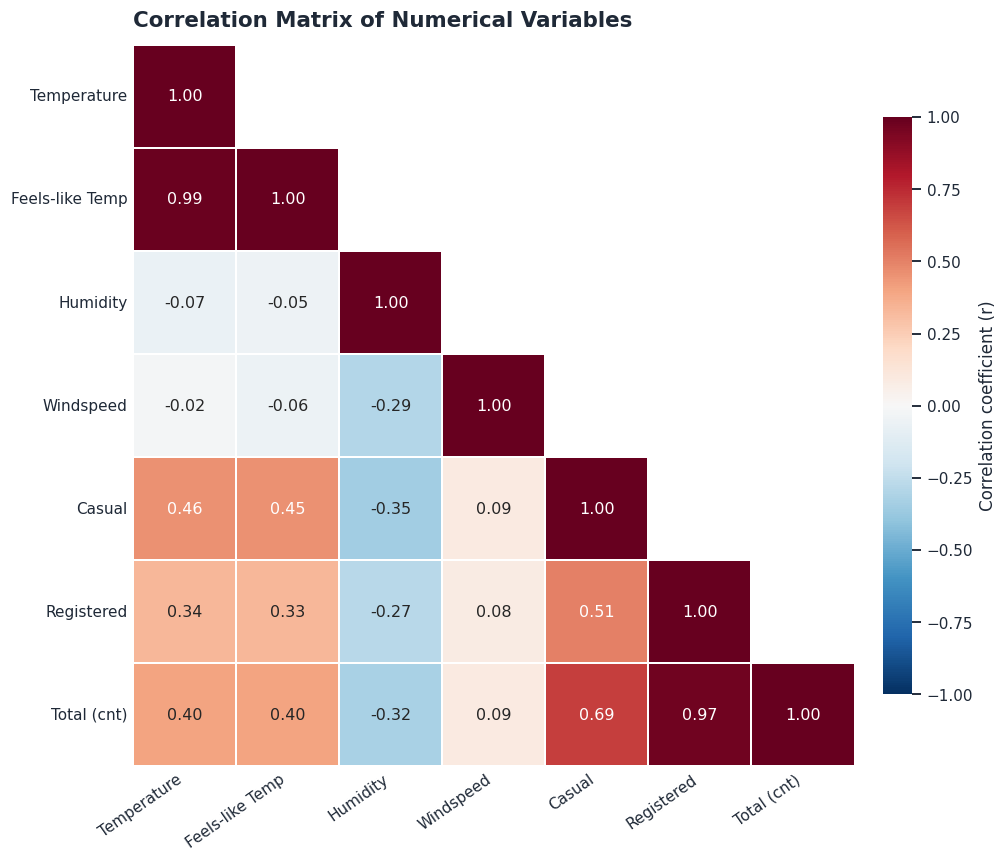

In [30]:
corr = df[numeric_cols].corr()

feature_names = {
    'temp': 'Temperature',
    'atemp': 'Feels-like Temp',
    'hum': 'Humidity',
    'windspeed': 'Windspeed',
    'casual': 'Casual',
    'registered': 'Registered',
    'cnt': 'Total (cnt)',
}
corr_plot = corr.rename(index=feature_names, columns=feature_names)
mask = np.triu(np.ones_like(corr_plot, dtype=bool), k=1)   # show lower triangle only

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_plot, mask=mask, cmap='RdBu_r', vmin=-1, vmax=1, center=0,
    annot=True, fmt='.2f', annot_kws={'size': 10.5},
    linewidths=1.2, linecolor='white', square=True,
    cbar_kws={'label': 'Correlation coefficient (r)', 'shrink': 0.8, 'pad': 0.03},
    ax=ax
)
ax.set_title('Correlation Matrix of Numerical Variables', loc='left', fontsize=14,
             fontweight='bold', color=TEXT_DARK, pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
ax.grid(False)
ax.tick_params(length=0)
plt.setp(ax.get_xticklabels(), rotation=35, ha='right')
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

In [31]:
target_corr = (
    df[numeric_cols]
    .corr()['cnt']
    .drop('cnt')
    .sort_values(key=abs, ascending=False)
)

target_corr

,cnt
registered,0.972151
casual,0.694564
temp,0.404772
atemp,0.400929
hum,-0.322911
windspeed,0.093234


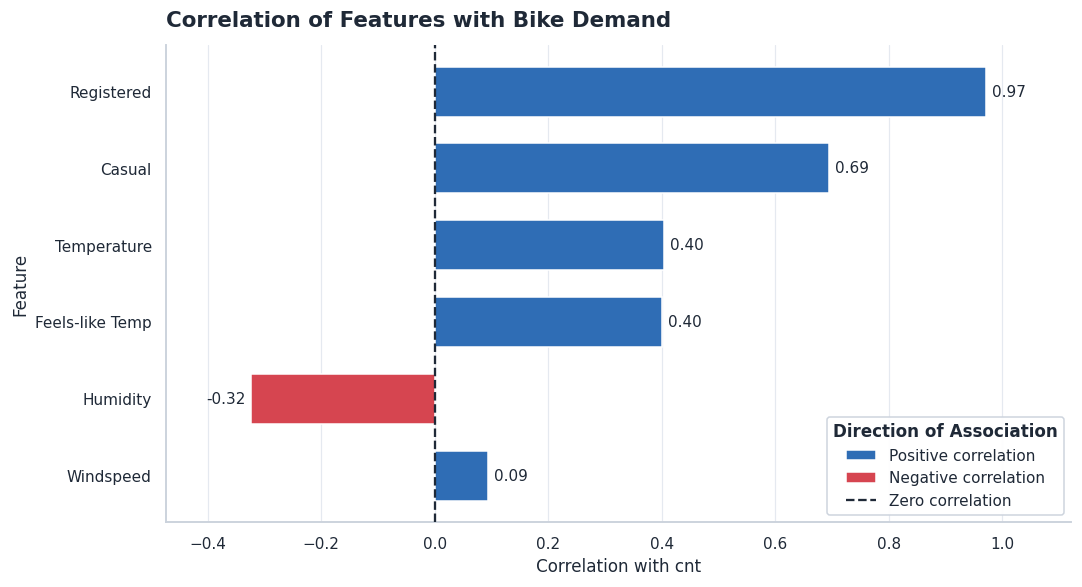

In [32]:
tc_labels = [feature_names.get(i, i) for i in target_corr.index]
tc_colors = [COLORS['blue'] if v >= 0 else COLORS['red'] for v in target_corr.values]

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(tc_labels, target_corr.values, color=tc_colors, edgecolor='white', height=0.65, zorder=2)
ax.axvline(0, color=TEXT_DARK, linestyle='--', linewidth=1.5, zorder=3)
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=10, color=TEXT_DARK)
ax.invert_yaxis()
ax.set_xlim(min(target_corr.min(), 0) - 0.15, max(target_corr.max(), 0) + 0.15)
style_axes(ax, 'Correlation of Features with Bike Demand', 'Correlation with cnt', 'Feature', grid_axis='x')

handles = [
    Patch(facecolor=COLORS['blue'], label='Positive correlation'),
    Patch(facecolor=COLORS['red'], label='Negative correlation'),
    Line2D([0], [0], color=TEXT_DARK, linestyle='--', linewidth=1.5, label='Zero correlation'),
]
add_legend(ax, handles, title='Direction of Association', loc='lower right')
plt.tight_layout()
plt.show()

In [33]:
weather_labels = {
    1: 'Clear',
    2: 'Mist/Cloudy',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}

df['weather_label'] = df['weathersit'].map(weather_labels)

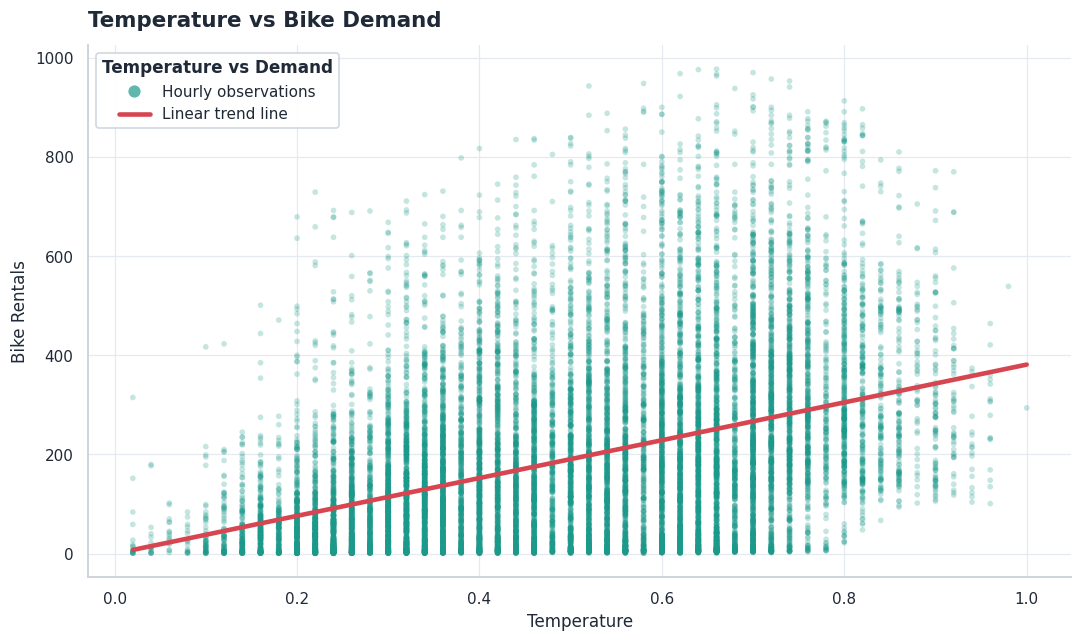

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df['temp'], df['cnt'], s=14, color=COLORS['teal'], alpha=0.25, edgecolor='none')
sns.regplot(data=df, x='temp', y='cnt', scatter=False, ci=None,
            line_kws={'color': COLORS['red'], 'linewidth': 3}, ax=ax)

handles = [
    Line2D([0], [0], marker='o', linestyle='none', markerfacecolor=COLORS['teal'],
           markeredgecolor='none', markersize=8, alpha=0.7, label='Hourly observations'),
    Line2D([0], [0], color=COLORS['red'], linewidth=3, label='Linear trend line'),
]
style_axes(ax, 'Temperature vs Bike Demand', 'Temperature', 'Bike Rentals', grid_axis='both')
add_legend(ax, handles, title='Temperature vs Demand', loc='upper left')
plt.tight_layout()
plt.show()

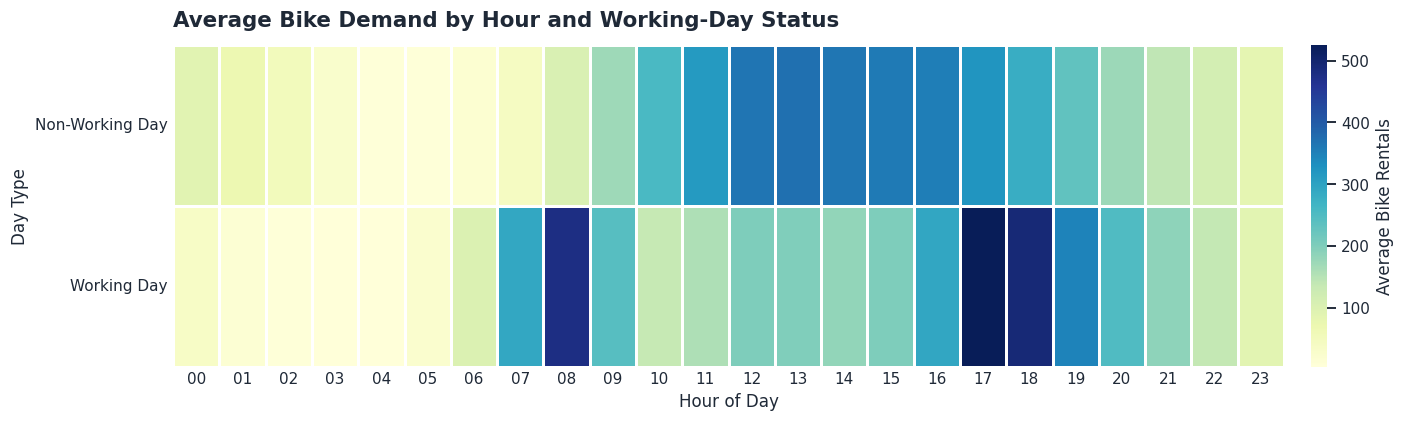

In [35]:
hour_working_pivot = (
    df.pivot_table(
        index='workingday',
        columns='hr',
        values='cnt',
        aggfunc='mean'
    )
)

hour_working_pivot.index = ['Non-Working Day', 'Working Day']

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    hour_working_pivot,
    cmap='YlGnBu',
    annot=False,
    linewidths=0.8,
    linecolor='white',
    cbar_kws={'label': 'Average Bike Rentals', 'pad': 0.02},
    ax=ax
)
ax.set_title('Average Bike Demand by Hour and Working-Day Status', loc='left',
             fontsize=14, fontweight='bold', color=TEXT_DARK, pad=12)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day Type')
ax.set_xticklabels([f'{int(h):02d}' for h in hour_working_pivot.columns], rotation=0)
plt.setp(ax.get_yticklabels(), rotation=0)
ax.grid(False)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

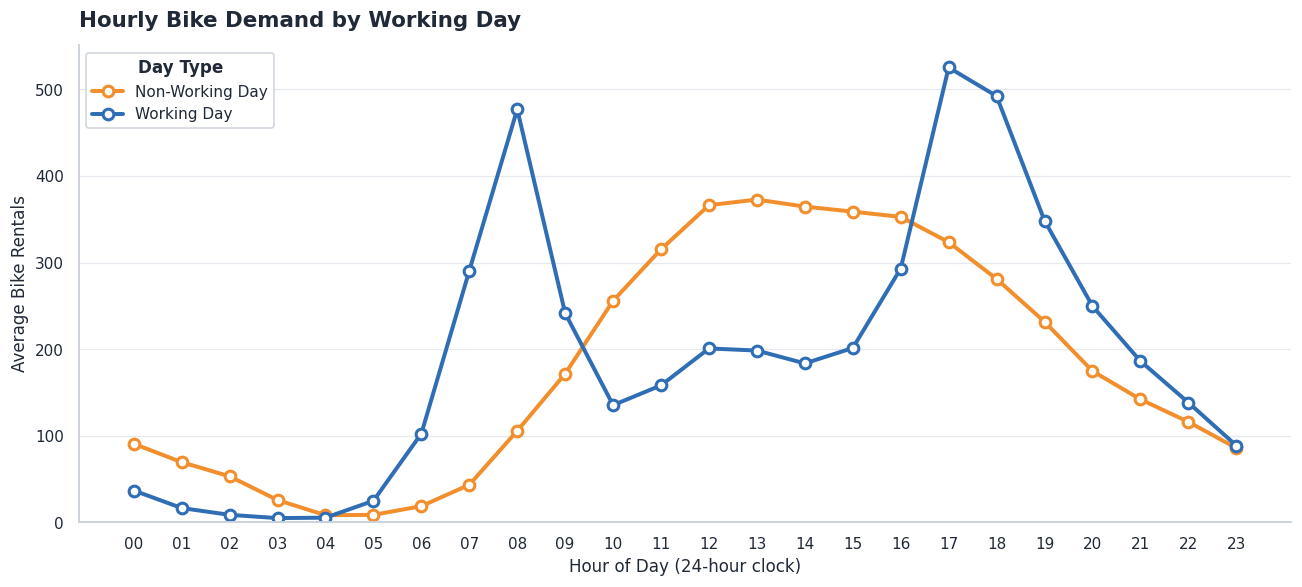

In [36]:
hour_working = (
    df.groupby(['hr', 'workingday'])['cnt']
    .mean()
    .reset_index()
)
hour_working['day_type'] = hour_working['workingday'].map({0: 'Non-Working Day', 1: 'Working Day'})

fig, ax = plt.subplots(figsize=(12, 5.5))
for day_type, color in DAY_COLORS.items():
    sub = hour_working[hour_working['day_type'] == day_type]
    ax.plot(sub['hr'], sub['cnt'], color=color, linewidth=2.6, marker='o', markersize=7,
            markerfacecolor='white', markeredgewidth=2, label=day_type)

ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}' for h in range(24)])
ax.set_ylim(bottom=0)
style_axes(ax, 'Hourly Bike Demand by Working Day', 'Hour of Day (24-hour clock)', 'Average Bike Rentals')
add_legend(ax, title='Day Type', loc='upper left')
plt.tight_layout()
plt.show()

In [37]:
user_hour = (
    df.groupby(['workingday', 'hr'])[['casual', 'registered']]
    .mean()
    .reset_index()
)

rows = []
for wd, label in [(0, 'Non-Working Day'), (1, 'Working Day')]:
    sub = user_hour[user_hour['workingday'] == wd]
    day_df = df[df['workingday'] == wd]
    rows.append({
        'Day Type': label,
        'Casual Peak Hour': int(sub.loc[sub['casual'].idxmax(), 'hr']),
        'Registered Peak Hour': int(sub.loc[sub['registered'].idxmax(), 'hr']),
        'Avg Casual per Hour': round(day_df['casual'].mean(), 2),
        'Avg Registered per Hour': round(day_df['registered'].mean(), 2),
        'Casual Share of Rentals (%)': round(100 * day_df['casual'].sum() / day_df['cnt'].sum(), 1),
    })

rider_type_summary = pd.DataFrame(rows)
rider_type_summary

,Day Type,Casual Peak Hour,Registered Peak Hour,Avg Casual per Hour,Avg Registered per Hour,Casual Share of Rentals (%)
0,Non-Working Day,14,12,57.44,123.96,31.7
1,Working Day,17,17,25.56,167.65,13.2


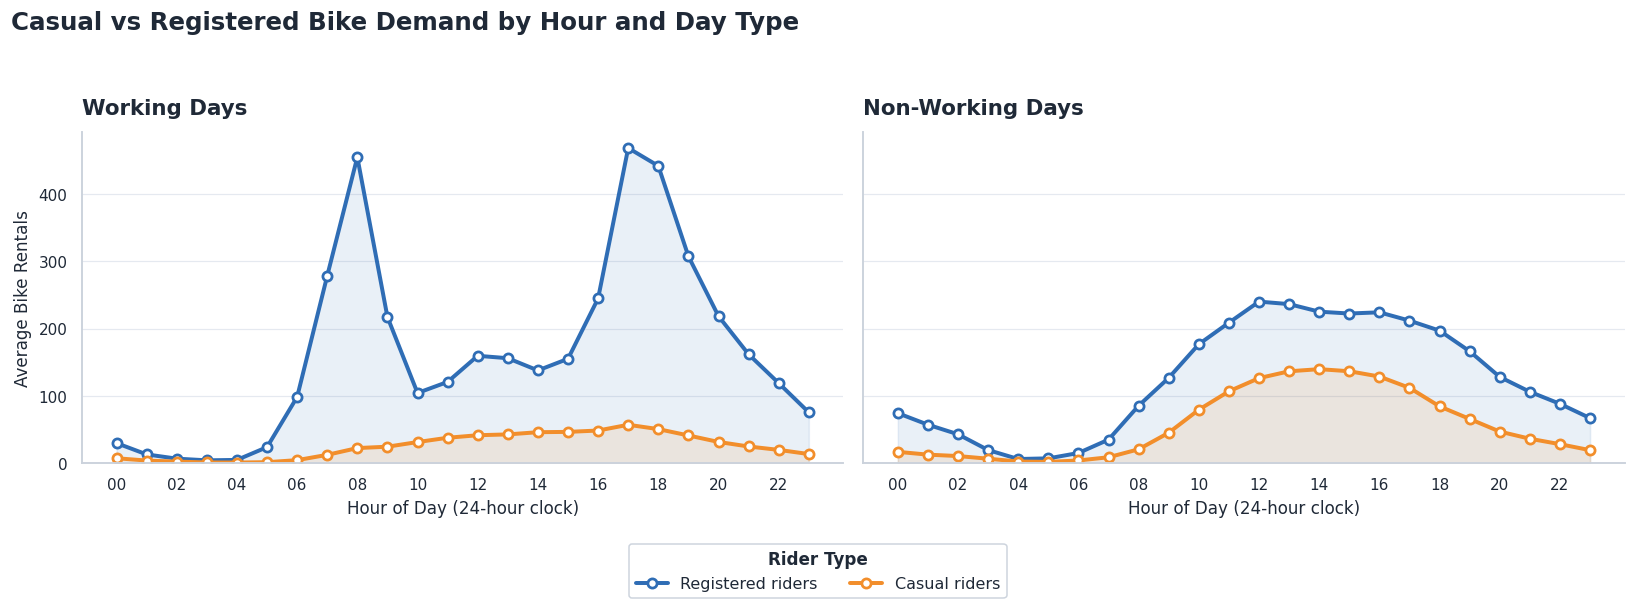

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)

for ax, (wd, panel_title) in zip(axes, [(1, 'Working Days'), (0, 'Non-Working Days')]):
    sub = user_hour[user_hour['workingday'] == wd]
    ax.plot(sub['hr'], sub['registered'], color=COLORS['blue'], linewidth=2.6, marker='o',
            markersize=6, markerfacecolor='white', markeredgewidth=1.8, label='Registered riders')
    ax.plot(sub['hr'], sub['casual'], color=COLORS['orange'], linewidth=2.6, marker='o',
            markersize=6, markerfacecolor='white', markeredgewidth=1.8, label='Casual riders')
    ax.fill_between(sub['hr'], sub['registered'], color=COLORS['blue'], alpha=0.10)
    ax.fill_between(sub['hr'], sub['casual'], color=COLORS['orange'], alpha=0.12)
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f'{h:02d}' for h in range(0, 24, 2)])
    ax.set_ylim(bottom=0)
    style_axes(ax, panel_title, 'Hour of Day (24-hour clock)',
               'Average Bike Rentals' if wd == 1 else '')

fig.suptitle('Casual vs Registered Bike Demand by Hour and Day Type', x=0.01, ha='left',
             fontsize=16, fontweight='bold', color=TEXT_DARK)

handles, labels = axes[0].get_legend_handles_labels()
leg = fig.legend(handles, labels, loc='lower center', ncol=2, title='Rider Type',
                 frameon=True, fancybox=True, edgecolor=EDGE_GREY, facecolor='white', fontsize=10.5)
leg.get_title().set_fontweight('bold')

plt.tight_layout(rect=[0, 0.11, 1, 0.94])
plt.show()

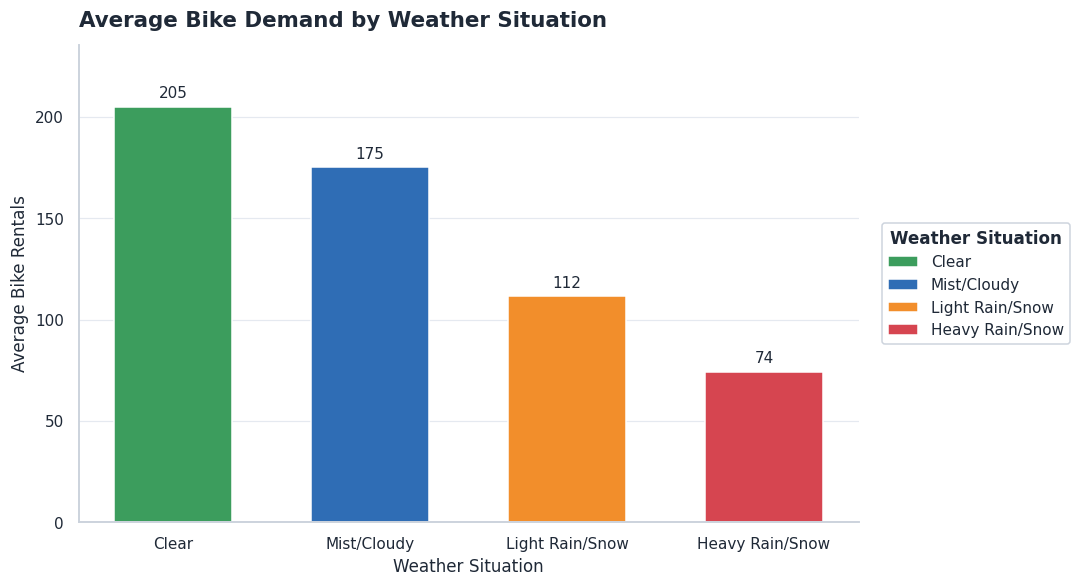

In [39]:
weather_demand = df.groupby('weather_label')['cnt'].mean().reindex(WEATHER_ORDER)

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(WEATHER_ORDER, weather_demand.values,
              color=[WEATHER_COLORS[w] for w in WEATHER_ORDER], edgecolor='white', width=0.6)
ax.bar_label(bars, labels=[f'{v:.0f}' if pd.notna(v) else '' for v in weather_demand.values],
             padding=4, fontsize=10, color=TEXT_DARK)
ax.set_ylim(0, weather_demand.max() * 1.15)
style_axes(ax, 'Average Bike Demand by Weather Situation', 'Weather Situation', 'Average Bike Rentals')
add_legend(ax, [Patch(facecolor=WEATHER_COLORS[w], label=w) for w in WEATHER_ORDER],
           title='Weather Situation', outside=True)
plt.tight_layout()
plt.show()

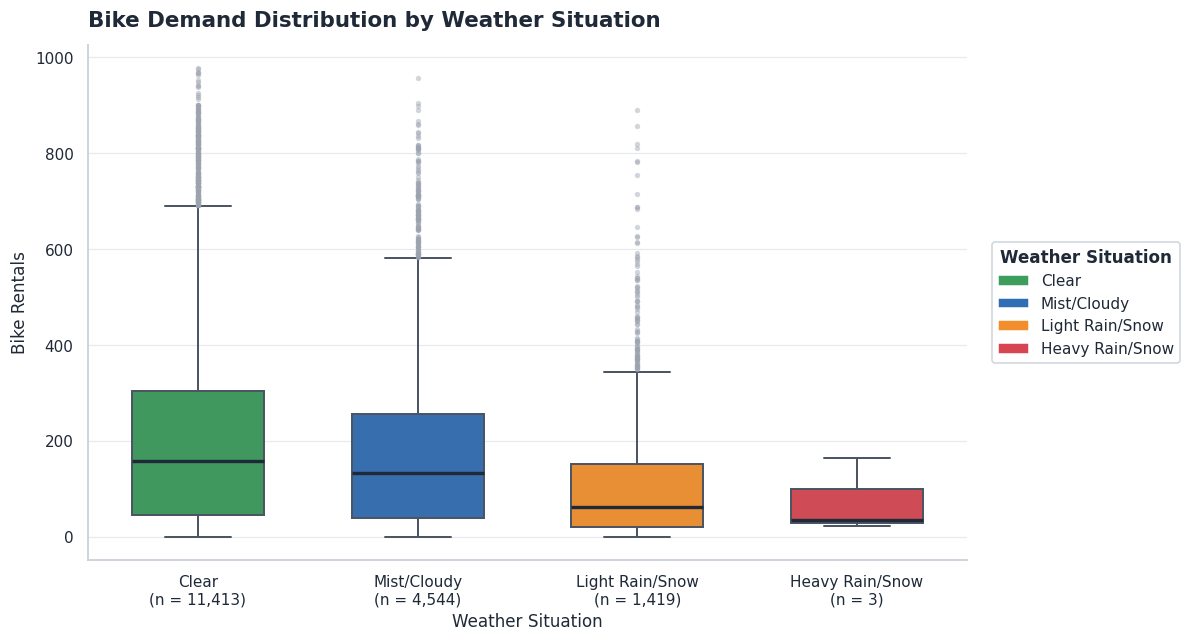

In [40]:
weather_order = [
    'Clear',
    'Mist/Cloudy',
    'Light Rain/Snow',
    'Heavy Rain/Snow'
]

# Sample size is shown under each category so the rare severe-weather groups are read carefully
weather_n = df['weather_label'].value_counts()
weather_tick_labels = [f"{w}\n(n = {weather_n.get(w, 0):,})" for w in weather_order]

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    data=df, x='weather_label', y='cnt', hue='weather_label',
    order=weather_order, hue_order=weather_order,
    palette=WEATHER_COLORS, legend=False, width=0.6, linewidth=1.3, saturation=0.9,
    linecolor='#4B5563',
    medianprops={'color': TEXT_DARK, 'linewidth': 2.2},
    flierprops={'marker': 'o', 'markerfacecolor': '#9CA3AF', 'markeredgecolor': 'none',
                'markersize': 3.5, 'alpha': 0.45},
    ax=ax
)
ax.set_xticks(range(len(weather_order)))
ax.set_xticklabels(weather_tick_labels)
style_axes(ax, 'Bike Demand Distribution by Weather Situation', 'Weather Situation', 'Bike Rentals')
add_legend(ax, [Patch(facecolor=WEATHER_COLORS[w], label=w) for w in weather_order],
           title='Weather Situation', outside=True)
plt.tight_layout()
plt.show()

In [41]:
weather_counts = df['weathersit'].value_counts().sort_index()
weather_counts

,count
weathersit,
1,11413
2,4544
3,1419
4,3


In [42]:
weather_percentage = (
    df['weather_label']
    .value_counts(normalize=True)
    .reindex(['Clear', 'Mist/Cloudy', 'Light Rain/Snow', 'Heavy Rain/Snow'])
    .mul(100)
)

weather_percentage

,proportion
weather_label,
Clear,65.671212
Mist/Cloudy,26.146499
Light Rain/Snow,8.165027
Heavy Rain/Snow,0.017262


In [43]:
working = df[df['workingday'] == 1]['cnt']
non_working = df[df['workingday'] == 0]['cnt']

t_stat, p_value = stats.ttest_ind(
    working,
    non_working,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 4.095067721524371
P-value: 4.249478377549554e-05


In [ ]:
if p_value < 0.05:
    print("The difference in average demand between working and non-working days is statistically significant.")
else:
    print("The difference in average demand between working and non-working days is not statistically significant.")

In [44]:
def add_cyclic_features(df):
    df = df.copy()
    df["sin_hr"] = np.sin(2 * np.pi * df["hr"] / 24.0)
    df["cos_hr"] = np.cos(2 * np.pi * df["hr"] / 24.0)
    df["sin_mnth"] = np.sin(2 * np.pi * df["mnth"] / 12.0)
    df["cos_mnth"] = np.cos(2 * np.pi * df["mnth"] / 12.0)
    return df


# Create cyclic features for hr and mnth
df = add_cyclic_features(df)

# Drop non-predictive/leakage columns (weather_label is an EDA-only text column) and define X, y
X = df.drop(columns=['instant', 'dteday', 'casual', 'registered', 'cnt', 'weather_label'])
y = df['cnt']

In [45]:
# Log-transform target
y_log = np.log1p(y)

# Random split (or use time-based split depending on your goal)
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

In [49]:
tscv = TimeSeriesSplit(n_splits=5)

# define hyperparameter grid search space
param_grid = {
    'n_estimators': [100],
    'max_depth': [15, 20],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1,verbose=2)

# perform grid search with time-series cv
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

print("running time-series cross-validation and hyperparameter tuning...")
grid_search.fit(X_train, y_train_log)

best_model = grid_search.best_estimator_
print(f"best parameters found: {grid_search.best_params_}")

running time-series cross-validation and hyperparameter tuning...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 2 of 100
building tree 1 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100building tree 6 of 100

building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    3.7s


building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81 of 100
building tree 82

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    8.5s finished


In [51]:
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_summary = cv_results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].copy()
cv_summary['mean_rmse'] = -cv_summary['mean_test_score']
cv_summary = cv_summary.sort_values(by='rank_test_score').reset_index(drop=True)

print("\n================ CROSS-VALIDATION COMPARISON TABLE ================")
display(cv_summary[['rank_test_score', 'params', 'mean_rmse', 'std_test_score']])


================ CROSS-VALIDATION COMPARISON TABLE ================


,rank_test_score,params,mean_rmse,std_test_score
0,1,"{'max_depth': 20, 'min_samples_split': 2, 'n_e...",0.339881,0.027391
1,2,"{'max_depth': 15, 'min_samples_split': 2, 'n_e...",0.340575,0.027039
2,3,"{'max_depth': 20, 'min_samples_split': 5, 'n_e...",0.341119,0.027378
3,4,"{'max_depth': 15, 'min_samples_split': 5, 'n_e...",0.341686,0.027399


In [52]:
joblib.dump(best_model, "model.pkl")

['model.pkl']

In [53]:
def evaluate_model(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = mean_absolute_percentage_error(actual, predicted) * 100

    # peak demand = top 10% of actual demand
    peak_threshold = np.quantile(actual, 0.90)
    peak_mask = actual >= peak_threshold
    peak_error = np.mean(np.abs(actual[peak_mask] - predicted[peak_mask]))

    return rmse, mape, peak_error

In [54]:
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test = np.expm1(y_test_log)

rf_rmse, rf_mape, rf_peak_error = evaluate_model(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

results = pd.DataFrame({
    'Model': ['Tuned Random Forest (CV Optimized)'],
    'RMSE': [round(rf_rmse, 2)],
    'R² Score': [round(r2, 4)],
    'MAPE (%)': [round(rf_mape, 2)],
    'Peak Error': [round(rf_peak_error, 2)]
})

print("\n================ FINAL MODEL PERFORMANCE ================")
display(results)


================ FINAL MODEL PERFORMANCE ================


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.1s finished


,Model,RMSE,R² Score,MAPE (%),Peak Error
0,Tuned Random Forest (CV Optimized),42.19,0.9438,27.38,54.35


In [55]:
predictions_df = X_test.copy()
predictions_df['Actual_Demand'] = y_test
predictions_df['Predicted_Demand'] = y_pred
predictions_df['Error'] = predictions_df['Actual_Demand'] - predictions_df['Predicted_Demand']
predictions_df['Absolute_Error'] = predictions_df['Error'].abs()

print("\n================ ACTUAL VS PREDICTED (FIRST 10 ROWS) ================")
display(predictions_df[['Actual_Demand', 'Predicted_Demand', 'Error', 'Absolute_Error']].head(10))


================ ACTUAL VS PREDICTED (FIRST 10 ROWS) ================


,Actual_Demand,Predicted_Demand,Error,Absolute_Error
12830,425.0,379.543375,45.456625,45.456625
8688,88.0,103.895173,-15.895173,15.895173
7091,4.0,10.286385,-6.286385,6.286385
12230,526.0,521.036782,4.963218,4.963218
431,13.0,14.514389,-1.514389,1.514389
1086,32.0,39.146675,-7.146675,7.146675
11605,706.0,754.345219,-48.345219,48.345219
7983,26.0,31.474100,-5.474100,5.474100
10391,2.0,8.136427,-6.136427,6.136427
7046,21.0,25.733010,-4.733010,4.733010


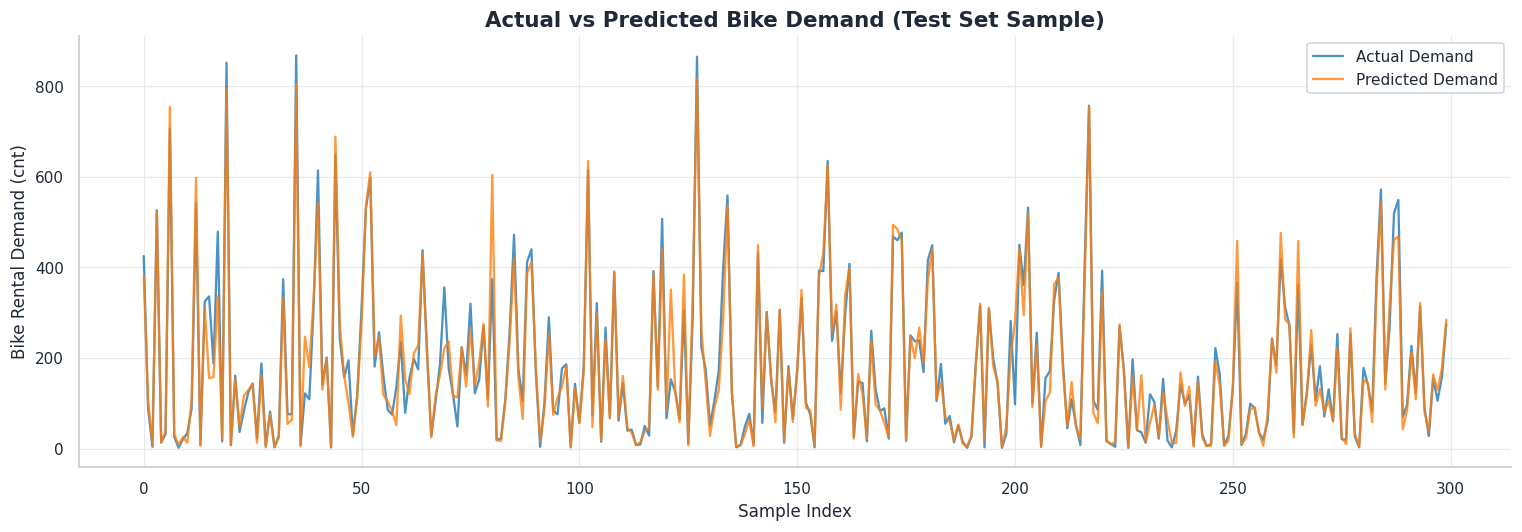

In [56]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:300], label='Actual Demand', color='tab:blue', alpha=0.8)
plt.plot(y_pred[:300], label='Predicted Demand', color='tab:orange', alpha=0.8)
plt.xlabel('Sample Index')
plt.ylabel('Bike Rental Demand (cnt)')
plt.title('Actual vs Predicted Bike Demand (Test Set Sample)')
plt.legend()
plt.tight_layout()
plt.show()

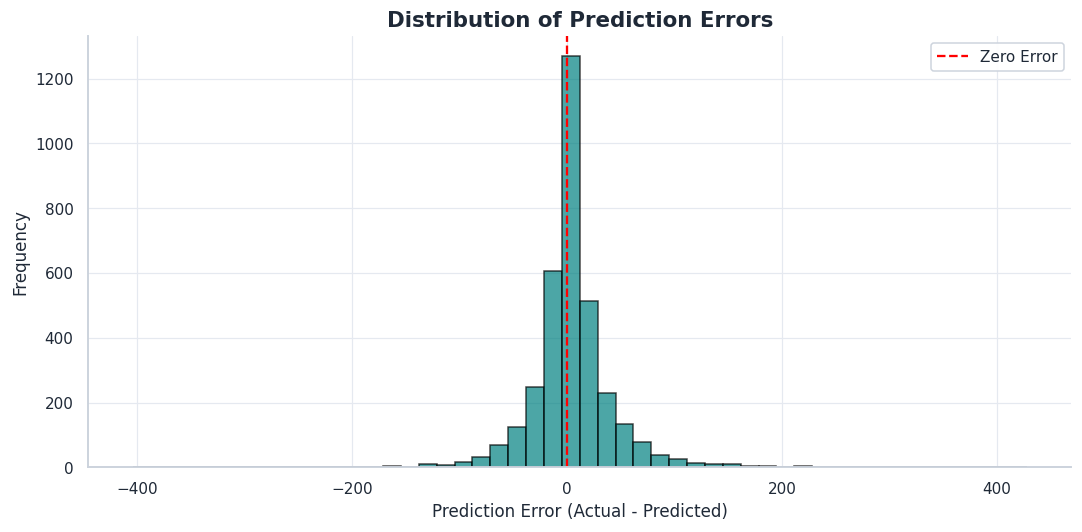

In [57]:
# prediction error histogram
plt.figure(figsize=(10, 5))
plt.hist(predictions_df['Error'], bins=50, color='teal', edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', label='Zero Error')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.legend()
plt.tight_layout()
plt.show()


================ TOP FEATURE IMPORTANCES ================


,Feature,Importance
0,hr,0.624053
1,cos_hr,0.070883
2,temp,0.062498
3,sin_hr,0.053931
4,workingday,0.052042
5,yr,0.029352
6,season,0.019076
7,atemp,0.018151
8,hum,0.015883
9,weathersit,0.014211


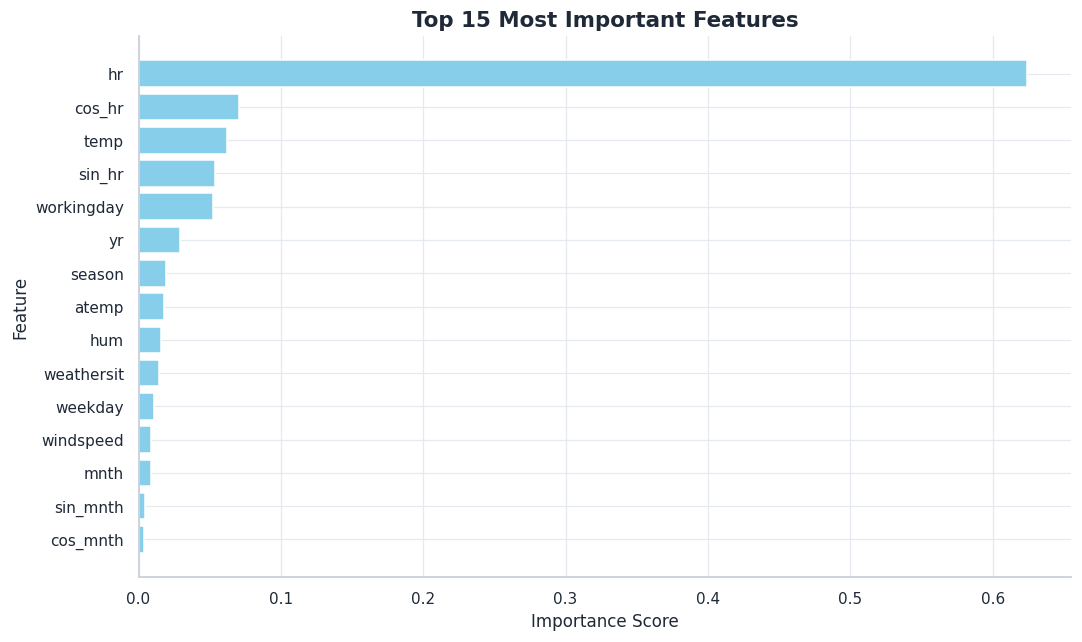

In [58]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("\n================ TOP FEATURE IMPORTANCES ================")
display(feature_importance.head(10))

#horizontal bar chart of feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'][:15][::-1], feature_importance['Importance'][:15][::-1], color='skyblue')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 15 Most Important Features')
plt.tight_layout()
plt.show()

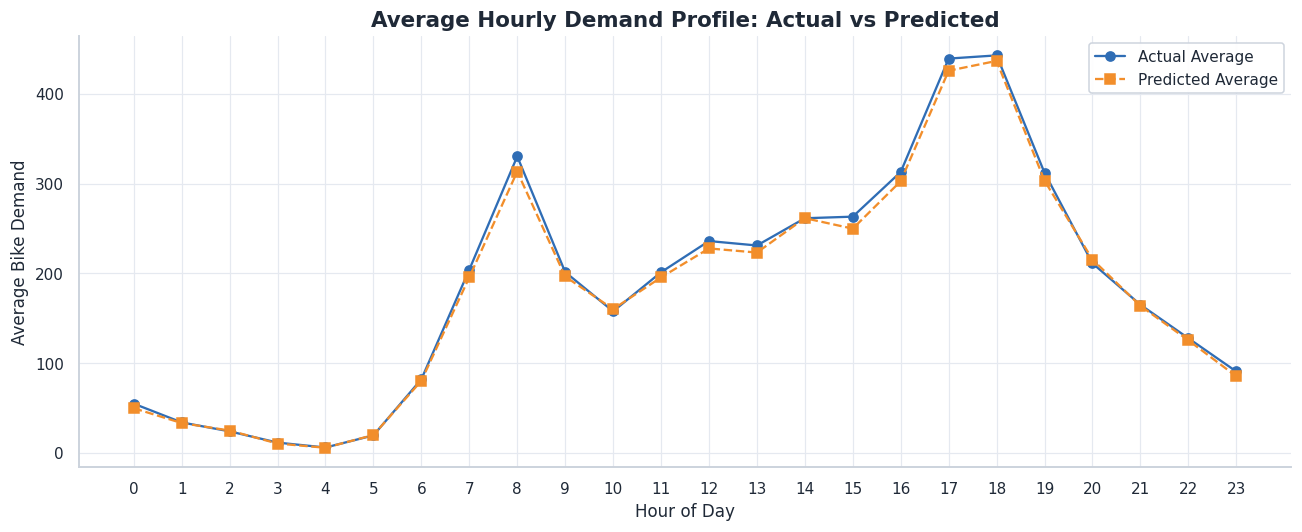

================ HOURLY BIKE REQUIREMENTS ================


,Actual Avg Bikes Needed,Model Predicted Bikes Needed
hr,,
18,443.0,437.0
17,439.0,426.0
8,330.0,314.0
16,313.0,303.0
19,312.0,303.0
15,263.0,250.0
14,262.0,262.0
12,236.0,228.0
13,231.0,223.0


In [59]:
hourly_analysis = predictions_df.groupby('hr').agg(
    Actual_Demand=('Actual_Demand', 'mean'),
    Predicted_Demand=('Predicted_Demand', 'mean')
).reset_index()

plt.figure(figsize=(12, 5))
plt.plot(hourly_analysis['hr'], hourly_analysis['Actual_Demand'], marker='o', label='Actual Average')
plt.plot(hourly_analysis['hr'], hourly_analysis['Predicted_Demand'], marker='s', linestyle='--', label='Predicted Average')
plt.xlabel('Hour of Day')
plt.ylabel('Average Bike Demand')
plt.title('Average Hourly Demand Profile: Actual vs Predicted')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

# view exact hourly demand requirement predicted by your model
hourly_summary = hourly_analysis.set_index('hr').round(0)
hourly_summary.columns = ['Actual Avg Bikes Needed', 'Model Predicted Bikes Needed']

print("================ HOURLY BIKE REQUIREMENTS ================")
display(hourly_summary.sort_values(by='Actual Avg Bikes Needed', ascending=False))

In [60]:
MODEL_COLUMNS = X.columns.tolist()

REQUIRED_COLUMNS = [
    "season", "yr", "mnth", "hr", "holiday", "weekday",
    "workingday", "weathersit", "temp", "atemp", "hum", "windspeed"
]

logging.basicConfig(
    filename="prediction_log.txt",
    level=logging.INFO,
    format="%(asctime)s | %(message)s"
)


def predict_demand(raw_input: dict) -> float:
    """
    Takes raw bike-share conditions as a dictionary and returns
    the predicted hourly bike demand.
    """
    missing = [c for c in REQUIRED_COLUMNS if c not in raw_input]
    if missing:
        raise ValueError(f"Missing required input fields: {missing}")

    df_in = pd.DataFrame([raw_input])
    df_in = add_cyclic_features(df_in)
    df_in = df_in[MODEL_COLUMNS]

    log_prediction = best_model.predict(df_in)[0]
    real_prediction = np.expm1(log_prediction)

    logging.info(f"Input: {raw_input} | Prediction: {real_prediction:.2f}")
    return real_prediction

In [61]:
row = df.iloc[100]

test_input = {
    "season": row["season"], "yr": row["yr"], "mnth": row["mnth"],
    "hr": row["hr"], "holiday": row["holiday"], "weekday": row["weekday"],
    "workingday": row["workingday"], "weathersit": row["weathersit"],
    "temp": row["temp"], "atemp": row["atemp"], "hum": row["hum"],
    "windspeed": row["windspeed"]
}

start = time.time()
result = predict_demand(test_input)
end = time.time()

print("Predicted:", result)
print("Actual cnt:", row["cnt"])
print(f"Latency: {(end - start) * 1000:.2f} ms")

try:
    predict_demand({"season": 1, "hr": 8})  # missing most fields on purpose
except ValueError as e:
    print("Caught expected error:", e)

Predicted: 121.80819678898798
Actual cnt: 115
Latency: 45.26 ms
Caught expected error: Missing required input fields: ['yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished


In [62]:
# ---------------------------------------------------------------------------
# ASSUMED SCENARIO PARAMETERS
# These values are NOT provided by the UCI dataset or project guide.
# ---------------------------------------------------------------------------

REVENUE_PER_RIDE = 3.50
HOLDING_COST_PER_BIKE = 0.75
REBALANCE_TRUCK_COST = 45.00
BIKES_PER_TRUCK_RUN = 150


def recommended_fleet(predicted_demand: pd.Series, safety_margin: float) -> pd.Series:
    """Convert model predictions into recommended fleet stock."""

    return np.ceil(
        predicted_demand * (1 + safety_margin)
    )


def classify_decision(
    stocked: pd.Series,
    actual_demand: pd.Series
) -> np.ndarray:
    """Classify each hour as UNDERSTOCK, OVERSTOCK, or OK."""

    diff = stocked - actual_demand

    return np.select(
        [
            diff < 0,
            diff > 0
        ],
        [
            "UNDERSTOCK",
            "OVERSTOCK"
        ],
        default="OK"
    )


def financial_impact(
    stocked: pd.Series,
    actual_demand: pd.Series
) -> pd.DataFrame:
    """Calculate lost rides, idle bikes, and their modeled costs."""

    lost_rides = np.clip(
        actual_demand - stocked,
        a_min=0,
        a_max=None
    )

    idle_bikes = np.clip(
        stocked - actual_demand,
        a_min=0,
        a_max=None
    )

    return pd.DataFrame({
        "lost_rides": lost_rides,
        "idle_bikes": idle_bikes,
        "lost_revenue": (
            lost_rides * REVENUE_PER_RIDE
        ),
        "holding_cost": (
            idle_bikes * HOLDING_COST_PER_BIKE
        )
    })


def daily_truck_cost(
    df_with_decision: pd.DataFrame
) -> pd.DataFrame:
    """
    Calculate daily truck-run cost based on
    additional bikes created by the safety margin.
    """

    added_bikes = (
        df_with_decision["recommended_fleet"]
        - df_with_decision["predicted_cnt"]
    ).clip(lower=0)

    daily = added_bikes.groupby(
        df_with_decision["dteday"]
    ).sum()

    trucks = np.ceil(
        daily / BIKES_PER_TRUCK_RUN
    )

    cost = (
        trucks * REBALANCE_TRUCK_COST
    ).rename("daily_truck_cost")

    return cost.reset_index()


def generate_decision_metrics(
    df: pd.DataFrame,
    safety_margin: float
) -> pd.DataFrame:
    """
    Full AE pipeline:

    model predictions
        -> safety margin
        -> recommended fleet
        -> operational decision
        -> financial impact

    Required columns:
    dteday
    actual_cnt
    predicted_cnt
    """

    out = df.copy()

    out["safety_margin"] = safety_margin

    out["recommended_fleet"] = recommended_fleet(
        out["predicted_cnt"],
        safety_margin
    )

    out["decision"] = classify_decision(
        out["recommended_fleet"],
        out["actual_cnt"]
    )

    impact = financial_impact(
        out["recommended_fleet"],
        out["actual_cnt"]
    )

    out = pd.concat(
        [
            out.reset_index(drop=True),
            impact.reset_index(drop=True)
        ],
        axis=1
    )

    out["net_operational_cost"] = (
        out["lost_revenue"]
        + out["holding_cost"]
    )

    trucks = daily_truck_cost(out)

    out = out.merge(
        trucks,
        on="dteday",
        how="left"
    )

    return out


def cost_matrix(
    decision_df: pd.DataFrame
) -> pd.DataFrame:
    """
    Confusion-cost-style summary adapted for
    the regression/business decision problem.

    Summarizes UNDERSTOCK, OVERSTOCK and OK decisions.
    """

    summary = decision_df.groupby(
        "decision"
    ).agg(
        hours=("decision", "size"),
        total_lost_rides=("lost_rides", "sum"),
        total_idle_bikes=("idle_bikes", "sum"),
        total_lost_revenue=("lost_revenue", "sum"),
        total_holding_cost=("holding_cost", "sum")
    ).reset_index()

    summary["pct_of_hours"] = (
        summary["hours"]
        / len(decision_df)
        * 100
    ).round(1)

    return summary


def tune_safety_margin(
    df: pd.DataFrame,
    margins=None
) -> pd.DataFrame:
    """
    Test different safety margins and calculate
    the modeled total cost for each margin.

    The tuning table is displayed in
    Metrics_Analysis.ipynb and is not saved
    as a separate CSV.
    """

    if margins is None:

        margins = np.round(
            np.arange(
                0.0,
                0.41,
                0.05
            ),
            2
        )

    rows = []

    for m in margins:

        metrics = generate_decision_metrics(
            df,
            m
        )

        total_truck_cost = (
            metrics
            .drop_duplicates("dteday")
            ["daily_truck_cost"]
            .sum()
        )

        rows.append({

            "safety_margin": m,

            "understock_hours": int(
                (
                    metrics["decision"]
                    == "UNDERSTOCK"
                ).sum()
            ),

            "overstock_hours": int(
                (
                    metrics["decision"]
                    == "OVERSTOCK"
                ).sum()
            ),

            "ok_hours": int(
                (
                    metrics["decision"]
                    == "OK"
                ).sum()
            ),

            "total_lost_revenue": round(
                metrics["lost_revenue"].sum(),
                2
            ),

            "total_holding_cost": round(
                metrics["holding_cost"].sum(),
                2
            ),

            "total_truck_cost": round(
                total_truck_cost,
                2
            ),

            "total_net_cost": round(
                metrics["net_operational_cost"].sum()
                + total_truck_cost,
                2
            )
        })

    return (
        pd.DataFrame(rows)
        .sort_values("total_net_cost")
        .reset_index(drop=True)
    )

In [63]:
print("ASSUMED business parameters")
print("(These values are scenario assumptions, not provided by the UCI dataset or project guide.)")
print()
print(f"Revenue per ride:              ${REVENUE_PER_RIDE}")
print(f"Holding cost per idle bike/hr: ${HOLDING_COST_PER_BIKE}")
print(f"Truck dispatch cost:           ${REBALANCE_TRUCK_COST}")
print(f"Truck capacity:                {BIKES_PER_TRUCK_RUN} bikes/run")

ASSUMED business parameters
(These values are scenario assumptions, not provided by the UCI dataset or project guide.)

Revenue per ride:              $3.5
Holding cost per idle bike/hr: $0.75
Truck dispatch cost:           $45.0
Truck capacity:                150 bikes/run


In [64]:
# Holdout predictions come straight from the trained model's test-set predictions
holdout = pd.DataFrame({
    "dteday": df.loc[predictions_df.index, "dteday"],
    "season": predictions_df["season"],
    "hr": predictions_df["hr"],
    "actual_cnt": df.loc[predictions_df.index, "cnt"],
    "predicted_cnt": predictions_df["Predicted_Demand"],
})
holdout = holdout.sort_values(["dteday", "hr"]).reset_index(drop=True)

print(f"Held-out hours: {len(holdout)}")
print(f"Period: {holdout['dteday'].min().date()} to {holdout['dteday'].max().date()}")

print("\nPrediction data:")
display(holdout.head())

Held-out hours: 3476
Period: 2011-01-01 to 2012-12-31

Prediction data:


,dteday,season,hr,actual_cnt,predicted_cnt
0,2011-01-01,1,3,13,10.771118
1,2011-01-01,1,5,1,4.202330
2,2011-01-01,1,8,8,35.055763
3,2011-01-01,1,14,106,118.185487
4,2011-01-01,1,19,37,48.195262


In [65]:
tuning_sheet = tune_safety_margin(holdout)

best_margin = float(
    tuning_sheet.iloc[0]["safety_margin"]
)

zero_cost = tuning_sheet.loc[
    tuning_sheet["safety_margin"] == 0,
    "total_net_cost"
].values[0]

savings = (
    zero_cost
    - tuning_sheet.iloc[0]["total_net_cost"]
)

print(f"Lowest-cost tested safety margin: {best_margin:.0%}")
print(
    f"Total net cost at {best_margin:.0%} margin: "
    f"${tuning_sheet.iloc[0]['total_net_cost']:,.2f}"
)
print(
    f"Total net cost at 0% margin: "
    f"${zero_cost:,.2f}"
)
print(
    f"Modeled cost difference: "
    f"${savings:,.2f}"
)

print("\nDecision Threshold Tuning Sheet:")
display(tuning_sheet)

print(
    f"\nThe lowest modeled cost occurred at {best_margin:.0%} "
    "among the tested 0%–40% safety margins."
)

Lowest-cost tested safety margin: 10%
Total net cost at 10% margin: $179,575.00
Total net cost at 0% margin: $234,037.50
Modeled cost difference: $54,462.50

Decision Threshold Tuning Sheet:


,safety_margin,understock_hours,overstock_hours,ok_hours,total_lost_revenue,total_holding_cost,total_truck_cost,total_net_cost
0,0.10,1039,2332,105,87293.5,54661.50,37620.0,179575.00
1,0.15,786,2593,97,63850.5,73123.50,46530.0,183504.00
2,0.05,1387,1969,120,122276.0,38680.50,32760.0,193716.50
3,0.20,601,2798,77,48720.0,93405.75,54675.0,196800.75
4,0.25,477,2930,69,38517.5,114718.50,63945.0,217181.00
5,0.00,1785,1579,112,174909.0,26458.50,32670.0,234037.50
6,0.30,381,3035,60,31202.5,136656.75,73935.0,241794.25
7,0.35,307,3104,65,25851.0,159021.00,82755.0,267627.00
8,0.40,256,3168,52,21682.5,181597.50,91800.0,295080.00



The lowest modeled cost occurred at 10% among the tested 0%–40% safety margins.


Safety margin applied: 10%

Cost Matrix / Decision Summary:


,decision,hours,total_lost_rides,total_idle_bikes,total_lost_revenue,total_holding_cost,pct_of_hours
0,OK,105,0.0,0.0,0.0,0.0,3.0
1,OVERSTOCK,2332,0.0,72882.0,0.0,54661.5,67.1
2,UNDERSTOCK,1039,24941.0,0.0,87293.5,0.0,29.9


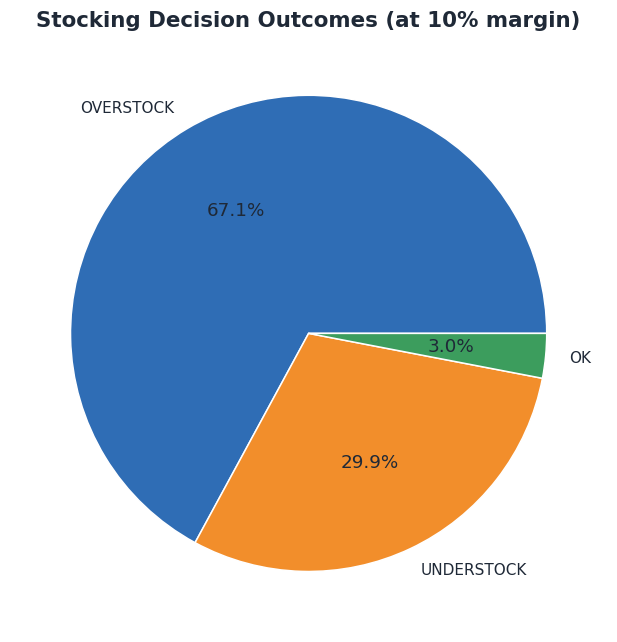

In [66]:
#  Cost Matrix and Decision Summary

metrics = generate_decision_metrics(
    holdout,
    safety_margin=best_margin
)

print(f"Safety margin applied: {best_margin:.0%}")

print("\nCost Matrix / Decision Summary:")
display(cost_matrix(metrics))

decision_counts = metrics["decision"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    decision_counts.values,
    labels=decision_counts.index,
    autopct="%1.1f%%"
)

plt.title(
    f"Stocking Decision Outcomes "
    f"(at {best_margin:.0%} margin)"
)

plt.tight_layout()
plt.show()

Net operational cost by season:


,net_operational_cost
Spring,39233.75
Fall,39073.50
Summer,36722.75
Winter,26925.00


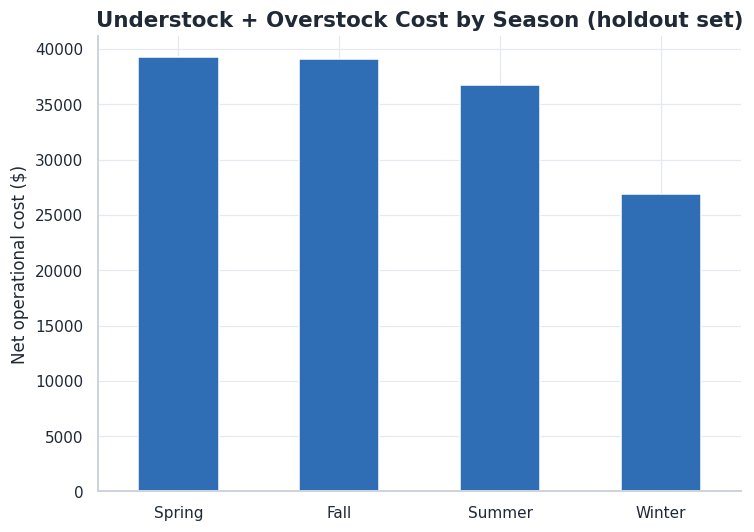

In [67]:
#  Seasonal Decision Analysis

season_labels = {
    1: "Winter",
    2: "Spring",
    3: "Summer",
    4: "Fall"
}

by_season = (
    metrics
    .groupby("season")["net_operational_cost"]
    .sum()
)

by_season.index = [
    season_labels[s]
    for s in by_season.index
]

by_season = by_season.sort_values(
    ascending=False
)

print("Net operational cost by season:")
display(by_season)

plt.figure(figsize=(7, 5))

by_season.plot(kind="bar")

plt.ylabel("Net operational cost ($)")
plt.title(
    "Understock + Overstock Cost by Season "
    "(holdout set)"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

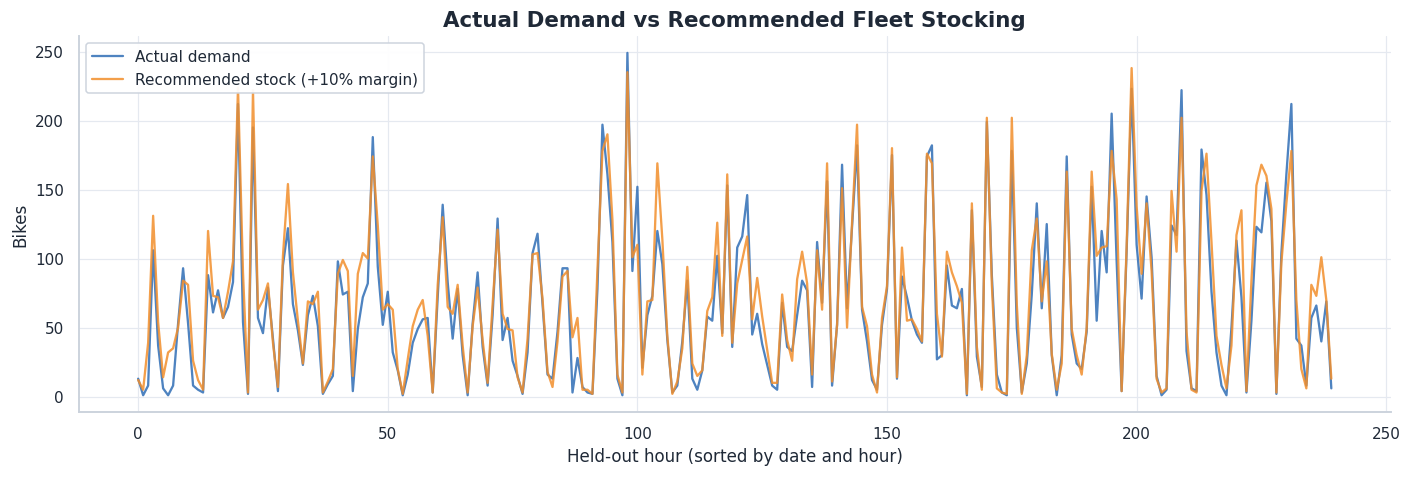

In [68]:
#  Actual vs. Recommended fleet

sample = (
    metrics
    .sort_values(["dteday", "hr"])
    .head(240)
)

plt.figure(figsize=(13, 4.5))

plt.plot(
    range(len(sample)),
    sample["actual_cnt"],
    label="Actual demand",
    alpha=0.85
)

plt.plot(
    range(len(sample)),
    sample["recommended_fleet"],
    label=f"Recommended stock (+{best_margin:.0%} margin)",
    alpha=0.85
)

plt.xlabel(
    "Held-out hour (sorted by date and hour)"
)

plt.ylabel("Bikes")

plt.title(
    "Actual Demand vs Recommended Fleet Stocking"
)

plt.legend()
plt.tight_layout()
plt.show()

In [69]:
#  Save Decision Metrics

metrics.to_csv(
    "Decision_Metrics.csv",
    index=False
)

print(
    f"Saved Decision_Metrics.csv "
    f"({len(metrics)} rows)"
)

print(
    "This is the row-level AE output used for "
    "business analysis and the BI/dashboard role."
)

Saved Decision_Metrics.csv (3476 rows)
This is the row-level AE output used for business analysis and the BI/dashboard role.
